In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [2]:
df = pd.read_csv('../dataset/cmi_internet_cleaned.csv')
X = df.drop(columns=['sii'])
y = np.array(df['sii'])

## **0. Preprocessing**

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [5]:
X_train.shape, y_train.shape            

((5487, 32), (5487,))

# 1. **Random Forest**

## 4 classes, imbalanced

Starting Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
Best Balanced Accuracy Score (CV): 0.3440

Evaluating Best Random Forest Model on Test Set...


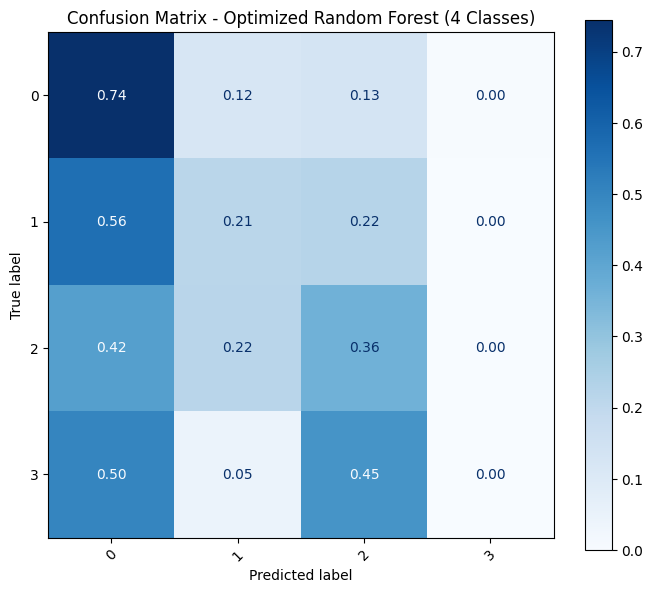

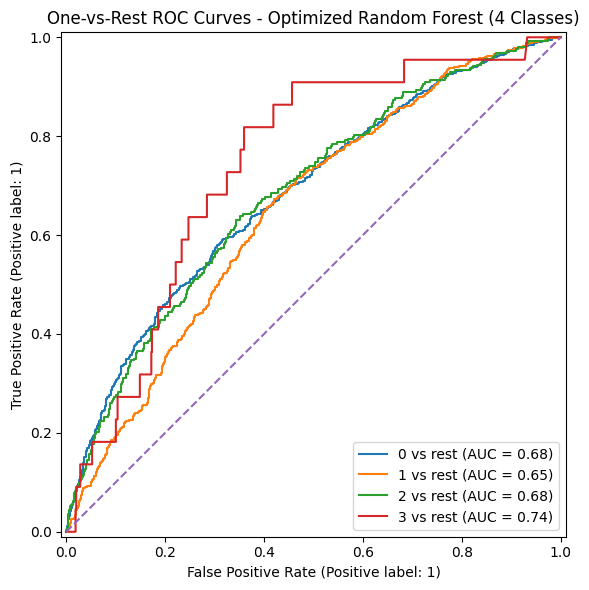

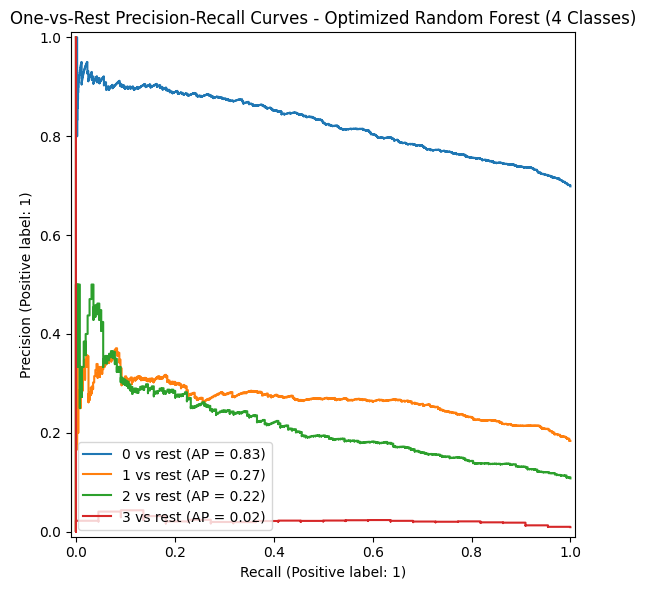


Classification report - Optimized Random Forest (4 Classes)


,precision,recall,f1-score,support
0,0.771753,0.744979,0.758129,1643.000000
1,0.269006,0.212471,0.237419,433.000000
2,0.221154,0.362205,0.274627,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.598639,0.598639,0.598639,0.598639
macro avg,0.315478,0.329914,0.317544,2352.000000
weighted avg,0.612518,0.598639,0.602961,2352.000000


In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from evaluate_classifier import evaluate_classifier

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist = {
    # Numero di alberi nella foresta
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità di ogni albero (previene l'overfitting)
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni richiesti per dividere un nodo interno
    'min_samples_split': [2, 5, 10],
    
    # Numero minimo di campioni richiesti in un nodo foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Numero di feature da considerare per la scelta del chunk migliore
    'max_features': ['sqrt', 'log2', None],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # STRATEGIA DI BILANCIAMENTO: 'balanced_subsample' calcola i pesi 
    # sulla combinazione bootstrap di ogni singolo albero (potentissimo)
    'class_weight': ['balanced', 'balanced_subsample']
    # queste opzioni aiutano a gestire dataset sbilanciati,
    # dando più peso alle classi minoritarie
}

# Modello base
rf_base = RandomForestClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Random Forest Hyperparameter Tuning...")

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation per massima stabilità
    scoring='balanced_accuracy',   # Ottimizziamo per la balanced accuracy
    n_jobs=-1,                     # Usa tutti i core della CPU disponibili
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati originali a 3 classi
random_search_rf.fit(X_train, y_train)

# Estrazione del modello migliore e dei parametri
best_rf = random_search_rf.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_rf.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_rf.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Random Forest Model on Test Set...")

# Utilizziamo la tua funzione evaluate_classifier originale passandogli direttamente il modello
results, report_df = evaluate_classifier(
    model=best_rf,
    X_test=X_test,       # Test set reale a 4 classi
    y_test=y_test,
    model_name="Optimized Random Forest (4 Classes)",
    normalize_cm="true"
)

## 3 classes, imbalanced

In [7]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (5487, 32), Test size: (2352, 32)


Starting Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
Best Balanced Accuracy Score (CV): 0.4671

Evaluating Best Random Forest Model on Test Set...


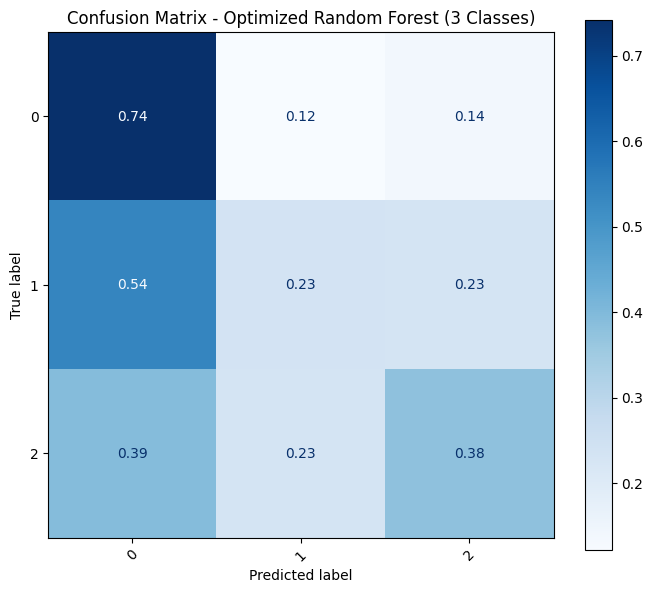

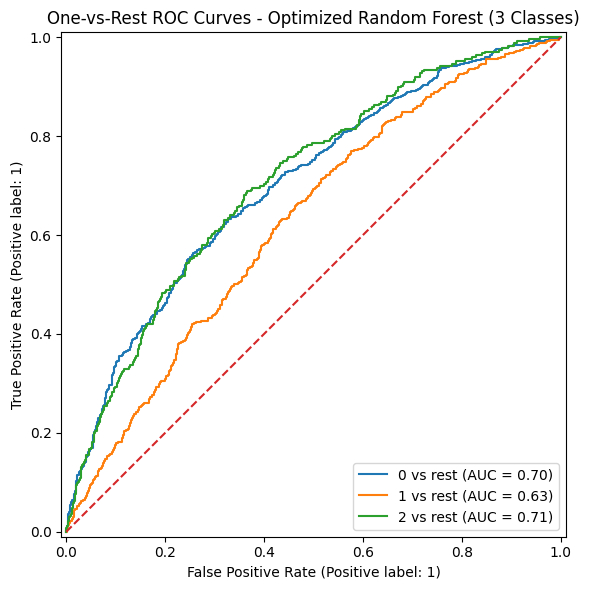

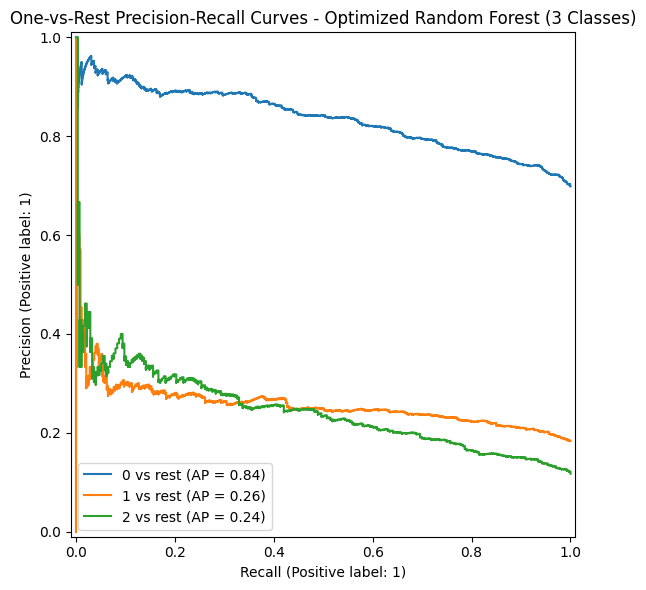


Classification report - Optimized Random Forest (3 Classes)


,precision,recall,f1-score,support
0,0.781410,0.741935,0.761161,1643.000000
1,0.276712,0.233256,0.253133,433.000000
2,0.243560,0.376812,0.295875,276.000000
accuracy,0.605442,0.605442,0.605442,0.605442
macro avg,0.433894,0.450668,0.436723,2352.000000
weighted avg,0.625381,0.605442,0.613034,2352.000000


In [8]:
# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist = {
    # Numero di alberi nella foresta
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità di ogni albero (previene l'overfitting)
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni richiesti per dividere un nodo interno
    'min_samples_split': [2, 5, 10],
    
    # Numero minimo di campioni richiesti in un nodo foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Numero di feature da considerare per la scelta del chunk migliore
    'max_features': ['sqrt', 'log2', None],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # STRATEGIA DI BILANCIAMENTO: 'balanced_subsample' calcola i pesi 
    # sulla combinazione bootstrap di ogni singolo albero (potentissimo)
    'class_weight': ['balanced', 'balanced_subsample']
}

# Modello base
rf_base = RandomForestClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Random Forest Hyperparameter Tuning...")

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation per massima stabilità
    scoring='balanced_accuracy',   # Ottimizziamo per la balanced accuracy
    n_jobs=-1,                     # Usa tutti i core della CPU disponibili
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati originali a 3 classi
random_search_rf.fit(X_train, y_train)

# Estrazione del modello migliore e dei parametri
best_rf = random_search_rf.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_rf.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_rf.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Random Forest Model on Test Set...")

# Utilizziamo la tua funzione evaluate_classifier originale passandogli direttamente il modello
results, report_df = evaluate_classifier(
    model=best_rf,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Random Forest (3 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (ENN)

Starting ENN + Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_depth': 10, 'rf__criterion': 'gini', 'rf__class_weight': 'balanced', 'enn__n_neighbors': 3, 'enn__kind_sel': 'mode'}
Best Balanced Accuracy Score (CV): 0.4702

Evaluating Best ENN + RF Model on Test Set...


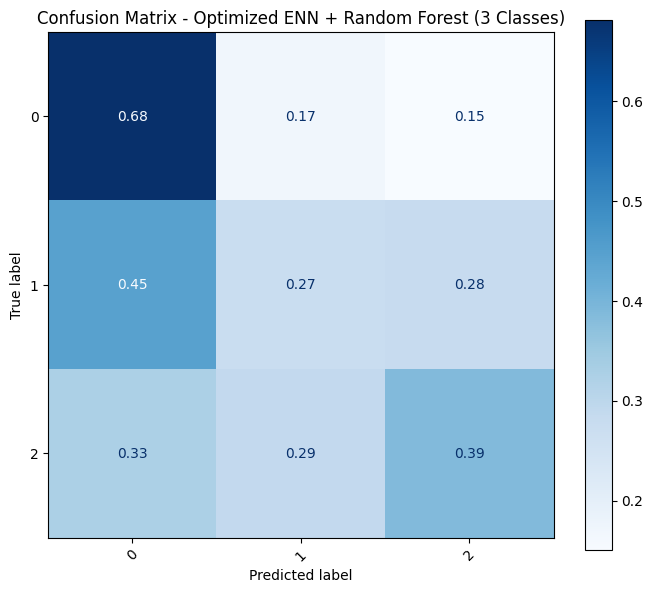

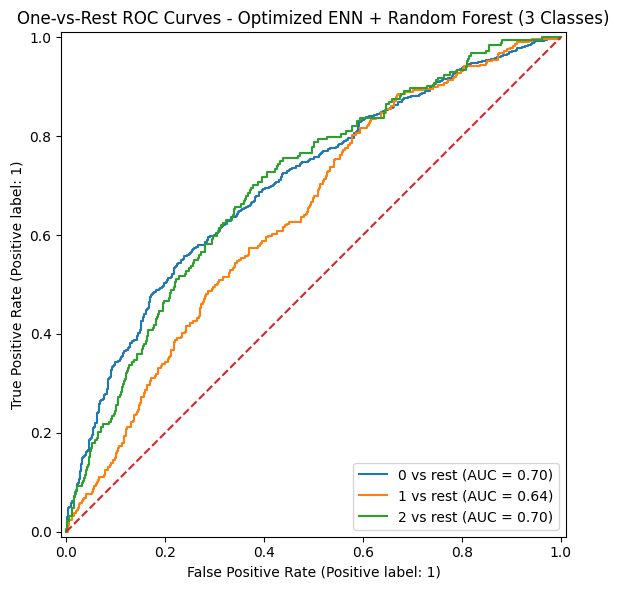

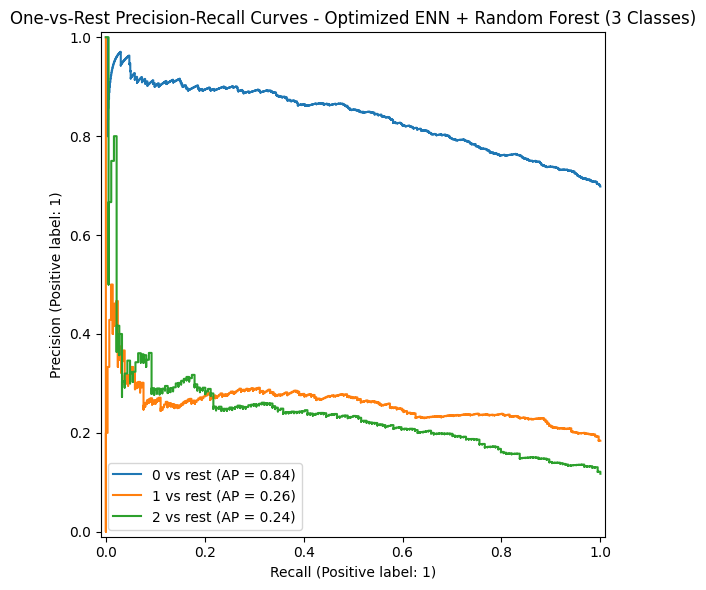


Classification report - Optimized ENN + Random Forest (3 Classes)


,precision,recall,f1-score,support
0,0.797861,0.681279,0.734975,1095.000000
1,0.250000,0.273356,0.261157,289.000000
2,0.223975,0.385870,0.283433,184.000000
accuracy,0.571429,0.571429,0.571429,0.571429
macro avg,0.423945,0.446835,0.426522,1568.000000
weighted avg,0.629540,0.571429,0.594658,1568.000000


In [16]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================================
# 1. SPAZIO IPERPARAMETRI (Con prefisso 'rf__' per la Pipeline)
# =========================================================================
param_dist = {
    # Parametri dell'ENN (Proviamo diversi numeri di vicini per la pulizia)
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], # 'all' è più aggressivo nell'eliminare i punti confusi
    
    # Parametri della Random Forest
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 10, 20, 30, 40],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__criterion': ['gini', 'entropy'],
    'rf__class_weight': [None, 'balanced'] # Vediamo se serve combinare ENN e pesi
}

# Inizializziamo i componenti base
enn_sampler = EditedNearestNeighbours(sampling_strategy='majority') # Rimuove campioni confusi dalla classe maggioritaria
rf_base = RandomForestClassifier(random_state=42)

# Costruiamo la pipeline protetta
pipeline_rf_enn = ImbPipeline([
    ('enn', enn_sampler), # Fase 1: Pulizia dei confini della classe maggioritaria
    ('rf', rf_base)       # Fase 2: Classificazione con Random Forest
])

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting ENN + Random Forest Hyperparameter Tuning...")

random_search_enn = RandomizedSearchCV(
    estimator=pipeline_rf_enn,
    param_distributions=param_dist,
    n_iter=50,                     # 50 combinazioni casuali
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla macro-media
    n_jobs=-1,                     
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati ORIGINALI a 3 classi sbilanciati
# La pipeline applicherà l'ENN fold per fold in modo sicuro
random_search_enn.fit(X_train, y_train)

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_enn.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_enn.best_score_:.4f}\n")

# Estraiamo il modello finale ottimizzato
best_pipeline_enn = random_search_enn.best_estimator_

# =========================================================================
# 3. VALUTAZIONE FINALE SUL TEST SET IMMACOLATO
# =========================================================================
print("Evaluating Best ENN + RF Model on Test Set...")

# La pipeline di scikit-learn/imblearn applicherà in automatico SOLO il predict 
# del modello finale sul test set, senza toccare geometricamente X_test.
results, report_df = evaluate_classifier(
    model=best_pipeline_enn,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized ENN + Random Forest (3 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

Starting Scaled ADASYN + ENN + Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_depth': 10, 'rf__criterion': 'gini', 'rf__class_weight': 'balanced_subsample', 'enn__n_neighbors': 7, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.4953

Evaluating Best Hybrid RF Model on Test Set...


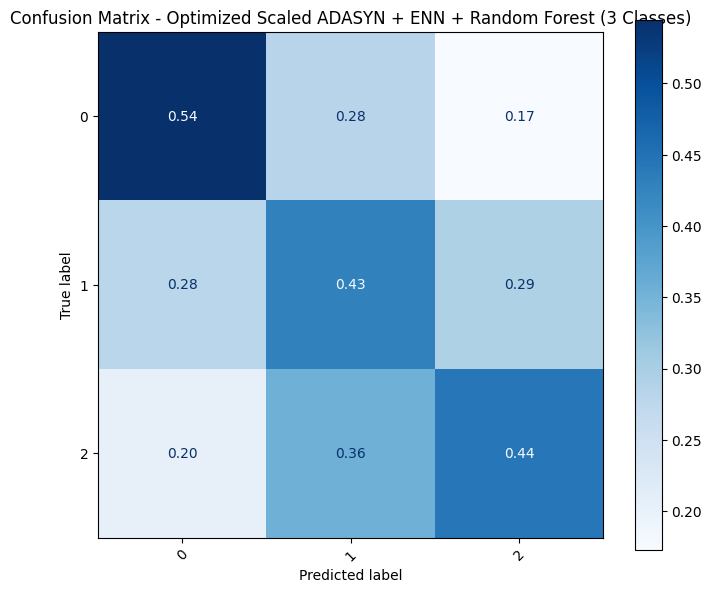

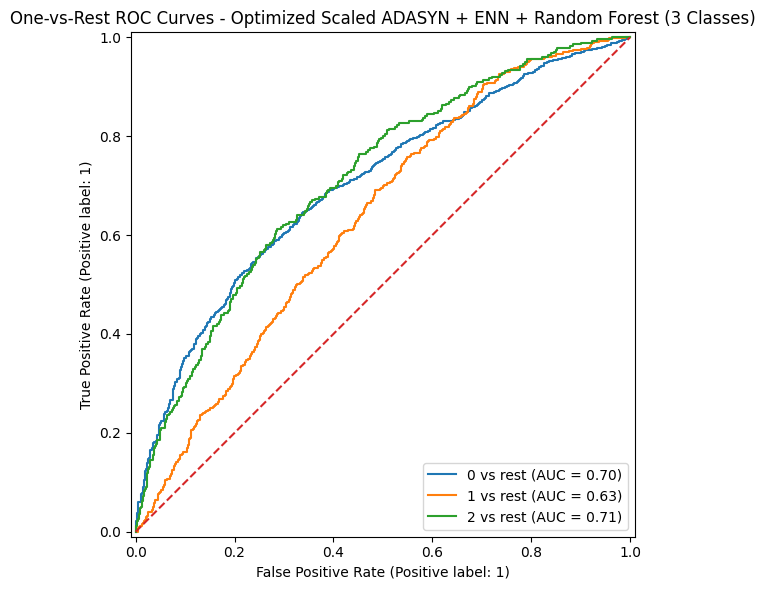

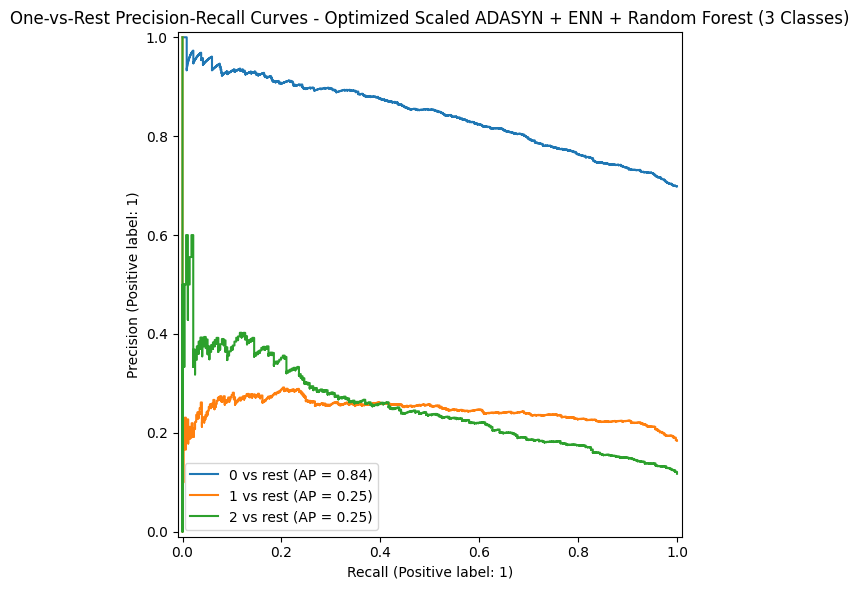


Classification report - Optimized Scaled ADASYN + ENN + Random Forest (3 Classes)


,precision,recall,f1-score,support
0,0.834888,0.544735,0.659300,1643.000000
1,0.247657,0.427252,0.313559,433.000000
2,0.228893,0.442029,0.301607,276.000000
accuracy,0.511054,0.511054,0.511054,0.511054
macro avg,0.437146,0.471339,0.424822,2352.000000
weighted avg,0.655668,0.511054,0.553676,2352.000000


In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler              
from imblearn.over_sampling import ADASYN                         
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================================
# 1. SPAZIO IPERPARAMETRI (Con prefissi per la Pipeline)
# =========================================================================
param_dist = {
    # Parametri ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], # 'all' pulisce i confini di tutte le classi
    
    # Parametri della Random Forest
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 10, 20, 30, 40],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__criterion': ['gini', 'entropy'],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample'] # Utile testarli anche con i sintetici
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE
# =========================================================================
# 1. Inizializziamo ADASYN
adasyn_sampler = ADASYN(random_state=42)

# 2. Inizializziamo ENN (deve pulire su 'all' perché ADASYN genera punti su più classi)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all') 

# 3. Modello base (Spostiamo n_jobs=-1 qui dentro per parallelizzare gli alberi in sicurezza)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# COSTRUZIONE DELLA PIPELINE PROTETTA (L'ordine è TASSATIVO)
pipeline_rf_hybrid = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione per far calcolare bene le distanze
    ('adasyn', adasyn_sampler),   # Fase 2: Oversampling basato sui K-NN (sui dati scalati)
    ('enn', enn_sampler),         # Fase 3: Pulizia basata sui K-NN (sui dati scalati)
    ('rf', rf_base)               # Fase 4: Classificazione (sui dati scalati, senza alcun impatto negativo)
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled ADASYN + ENN + Random Forest Hyperparameter Tuning...")

random_search_hybrid = RandomizedSearchCV(
    estimator=pipeline_rf_hybrid,
    param_distributions=param_dist,
    n_iter=50,                     # 50 combinazioni casuali
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla macro-media delle recall
    n_jobs=1,                      # IMPERATIVO: Mantenere 1 qui per evitare che joblib/imblearn vadano in crash
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati ORIGINALI a 3 classi sbilanciati e NON scalati.
# Ci penserà lo 'scaler' interno alla pipeline a standardizzarli fold per fold.
random_search_hybrid.fit(X_train, y_train)

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid.best_score_:.4f}\n")

# Estraiamo la pipeline finale ottimizzata
best_pipeline_hybrid = random_search_hybrid.best_estimator_

from evaluate_classifier import evaluate_classifier
# =========================================================================
# 4. VALUTAZIONE FINALE SUL TEST SET IMMACOLATO
# =========================================================================
print("Evaluating Best Hybrid RF Model on Test Set...")

# La pipeline di scikit-learn applicherà in automatico StandardScaler (usando medie/std del train),
# salterà ADASYN/ENN (perché non si usano in predizione) e farà il predict sul modello finale.
results, report_df = evaluate_classifier(
    model=best_pipeline_hybrid,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized Scaled ADASYN + ENN + Random Forest (3 Classes)",
    normalize_cm="true"
)

### Feature importance of the best tree

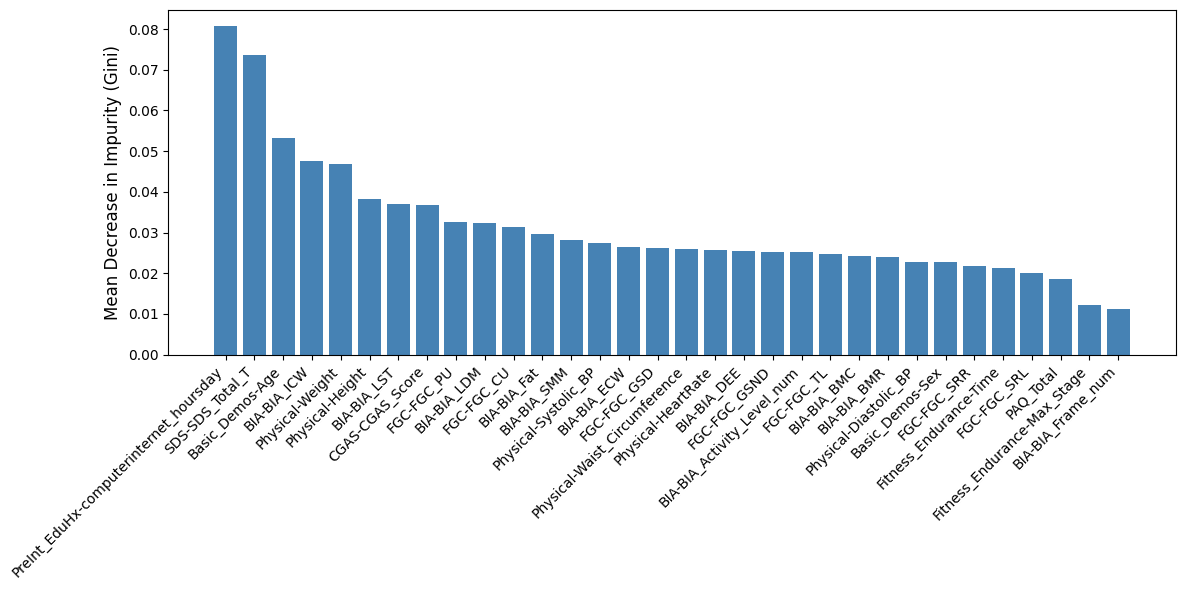

In [13]:
# Feature importance plot
# ==============================================================================
# 1. ESTRAZIONE DEL MODELLO DALLA PIPELINE
# ==============================================================================
# Estraiamo SOLO la Random Forest dalla pipeline vincente
rf_model = best_pipeline_hybrid.named_steps['rf']

# ==============================================================================
# 2. CALCOLO E ORDINAMENTO DELLE IMPORTANCES
# ==============================================================================
importances = rf_model.feature_importances_
feature_names = X_train.columns  # Usiamo X_train per sicurezza

# Ordiniamo gli indici dal più importante al meno importante
sorted_indices = np.argsort(importances)[::-1]

# ==============================================================================
# 3. CREAZIONE DEL PLOT (Formato Tesi)
# ==============================================================================
plt.figure(figsize=(12, 6)) # Leggermente allargato per far respirare le etichette

plt.bar(
    range(len(importances)), 
    importances[sorted_indices], 
    align='center',
    color='steelblue' # Un colore sobrio e accademico
)

# Impostiamo le etichette sull'asse X
# rotation=45 e ha='right' allineano i testi in diagonale per renderli leggibili
plt.xticks(
    range(len(importances)), 
    feature_names[sorted_indices], 
    rotation=45, 
    ha='right',
    fontsize=10
)

#plt.title("Feature Importances - Optimized ADASYN + ENN + Random Forest", fontsize=14, pad=15)
plt.ylabel("Mean Decrease in Impurity (Gini)", fontsize=12) # Il vero nome matematico dell'importanza di RF

plt.tight_layout()
plt.show()

### Permutation importance

Permutation importance è un metodo più robusto per valutare l'importanza delle feature, in quanto misura l'impatto sulla performance del modello quando i valori di una feature vengono casualmente shufflati, rompendo così la relazione tra quella feature e il target. Questo metodo è particolarmente utile per modelli complessi come le random forest, dove l'importanza basata sui criteri di divisione può essere fuorviante a causa di correlazioni tra le feature o di bias verso feature con più livelli.

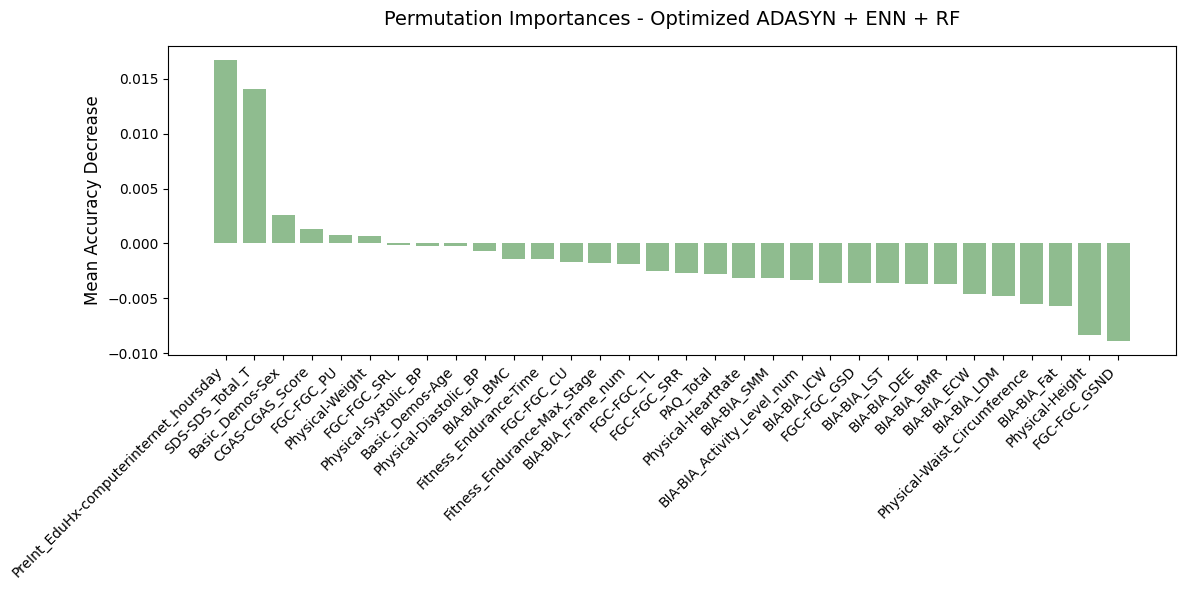

In [11]:
from sklearn.inspection import permutation_importance

# ==============================================================================
# 1. CALCOLO DELLA PERMUTATION IMPORTANCE (SULL'INTERA PIPELINE)
# ==============================================================================
# Passiamo l'intera pipeline e il Test Set. 
# Lo scaler interno adatterà i dati automaticamente, ignorando ADASYN/ENN.
perm_importance = permutation_importance(
    best_pipeline_hybrid, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1  # Parallelizziamo per velocizzare le 10 ripetizioni
)

# ==============================================================================
# 2. ORDINAMENTO DEI RISULTATI
# ==============================================================================
feature_names = X_train.columns
perm_sorted_indices = np.argsort(perm_importance.importances_mean)[::-1]

# ==============================================================================
# 3. CREAZIONE DEL PLOT (Formato Tesi)
# ==============================================================================
plt.figure(figsize=(12, 6))

plt.bar(
    range(len(perm_importance.importances_mean)), 
    perm_importance.importances_mean[perm_sorted_indices], 
    align='center',
    color='darkseagreen' # Cambiamo colore per distinguerlo dal grafico di Gini
)

plt.xticks(
    range(len(perm_importance.importances_mean)), 
    feature_names[perm_sorted_indices], 
    rotation=45, 
    ha='right',
    fontsize=10
)

plt.title("Permutation Importances - Optimized ADASYN + ENN + RF", fontsize=14, pad=15)
plt.ylabel("Mean Accuracy Decrease", fontsize=12)

plt.tight_layout()
plt.show()

### First Tree visualization

In [12]:
'''# plot the first tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(40, 10))
# best_rf.estimators_[0] corresponds to the first tree in the forest
plot_tree(best_rf.estimators_[0], filled=True, feature_names=X.columns, class_names=['0', '1', '2', '3'], max_depth=3, fontsize=12, rounded=True)  # Limitiamo la profondità per una visualizzazione chiara
#plt.title("Visualization of One Tree from the Optimized Random Forest")
plt.show()'''

'# plot the first tree \nfrom sklearn.tree import plot_tree\nplt.figure(figsize=(40, 10))\n# best_rf.estimators_[0] corresponds to the first tree in the forest\nplot_tree(best_rf.estimators_[0], filled=True, feature_names=X.columns, class_names=[\'0\', \'1\', \'2\', \'3\'], max_depth=3, fontsize=12, rounded=True)  # Limitiamo la profondità per una visualizzazione chiara\n#plt.title("Visualization of One Tree from the Optimized Random Forest")\nplt.show()'

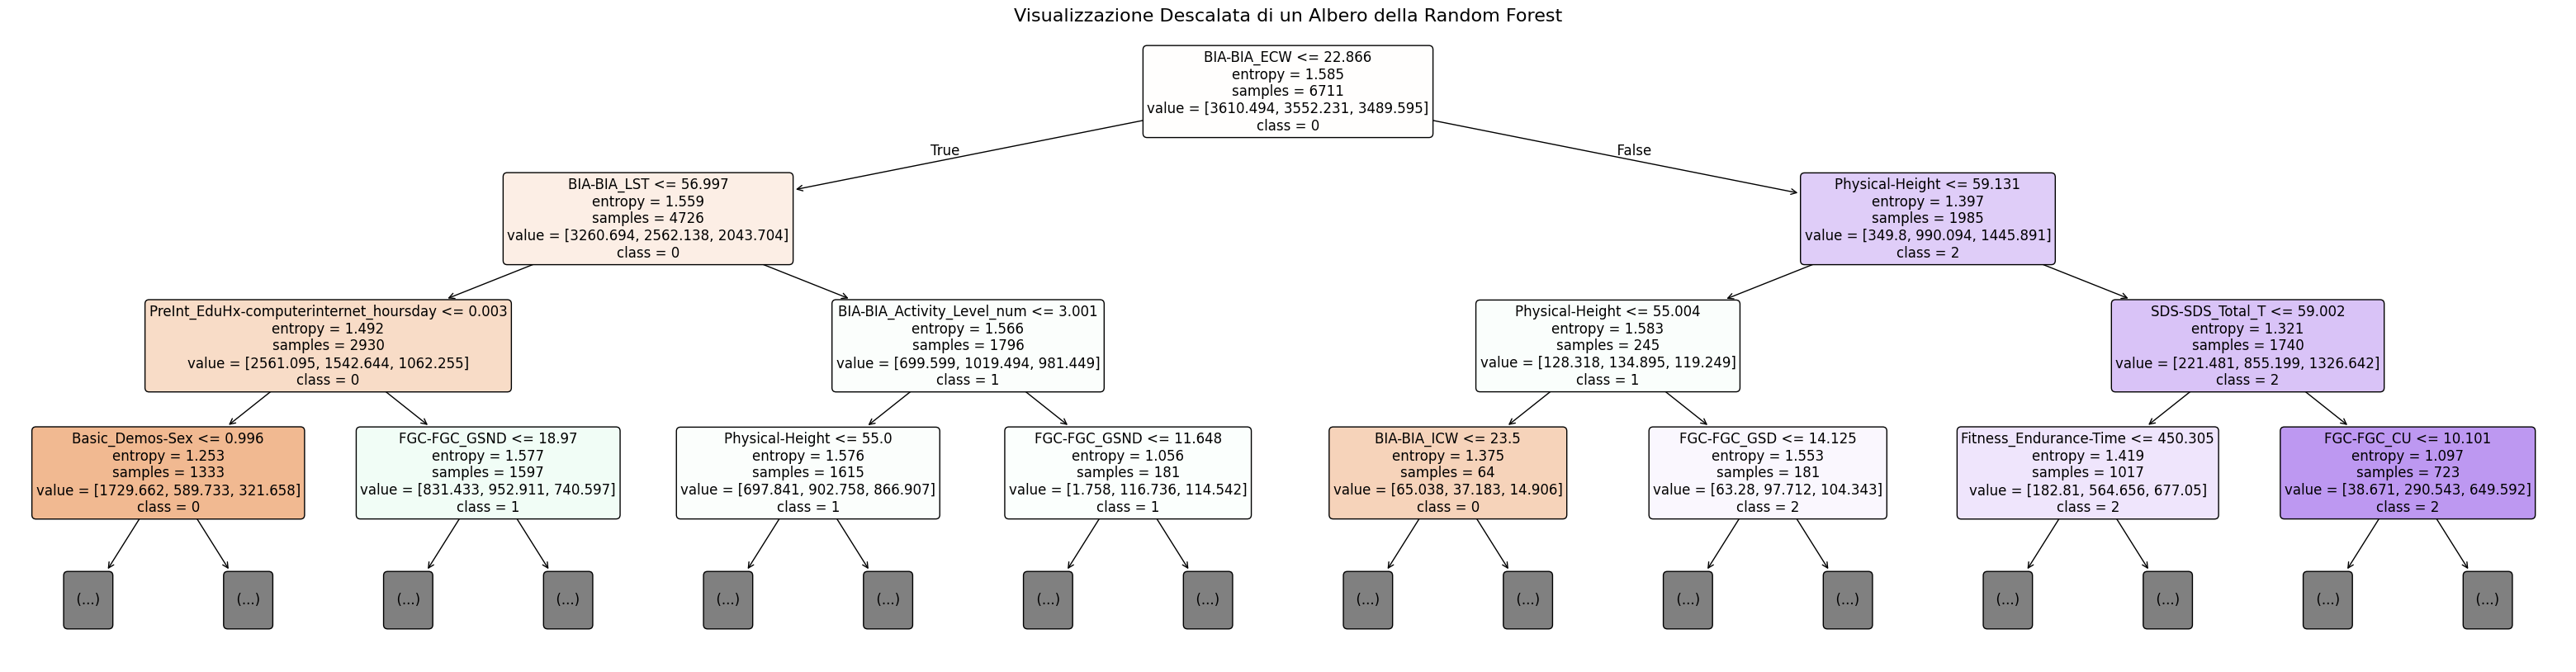

In [10]:
import copy
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ==============================================================================
# 1. ESTRAZIONE COMPONENTI DALLA PIPELINE
# ==============================================================================
# Estraiamo lo StandardScaler e la Random Forest dalla pipeline ottimizzata
scaler = best_pipeline_hybrid.named_steps['scaler']
rf_model = best_pipeline_hybrid.named_steps['rf']

# Estraiamo il primo albero della foresta e ne facciamo una COPIA PROFONDA.
# È vitale usare deepcopy, altrimenti modificheremmo il modello in modo permanente!
tree_to_plot = copy.deepcopy(rf_model.estimators_[0])

# ==============================================================================
# 2. INVERSIONE MATEMATICA DELLE SOGLIE (THRESHOLDS)
# ==============================================================================
# Recuperiamo le medie e le deviazioni standard apprese dallo scaler sul Train Set
means = scaler.mean_
scales = scaler.scale_

# Accediamo alla struttura a basso livello dell'albero in C (tree_.feature e tree_.threshold)
for i, feature_index in enumerate(tree_to_plot.tree_.feature):
    # In Scikit-Learn, i nodi foglia hanno il valore feature impostato a -2
    if feature_index != -2: 
        # Applichiamo la formula inversa della standardizzazione:
        # Valore_Originale = (Valore_Scalato * Deviazione_Standard) + Media
        tree_to_plot.tree_.threshold[i] = (tree_to_plot.tree_.threshold[i] * scales[feature_index]) + means[feature_index]

# ==============================================================================
# 3. PLOT DELL'ALBERO DE-SCALATO
# ==============================================================================
plt.figure(figsize=(40, 10))

plot_tree(
    tree_to_plot, 
    filled=True, 
    feature_names=X_train.columns.tolist(), # I nomi delle variabili originali
    class_names=['0', '1', '2'],            # Metti ['0', '1', '2', '3'] se sei nello scenario a 4 classi
    max_depth=3,                            # Limitiamo per leggibilità
    fontsize=12, 
    rounded=True
)

plt.title("Visualizzazione Descalata di un Albero della Random Forest", fontsize=16)
plt.show()

# 2. **ExtraTreesClassifier**

## 4 classes, imbalanced

Starting Extra Trees Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
Best Balanced Accuracy Score (CV): 0.3759

Evaluating Best Extra Trees Model on Test Set...


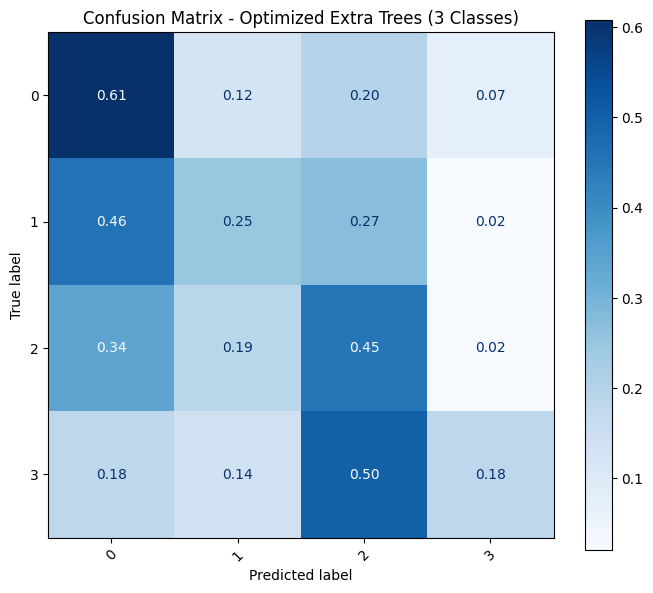

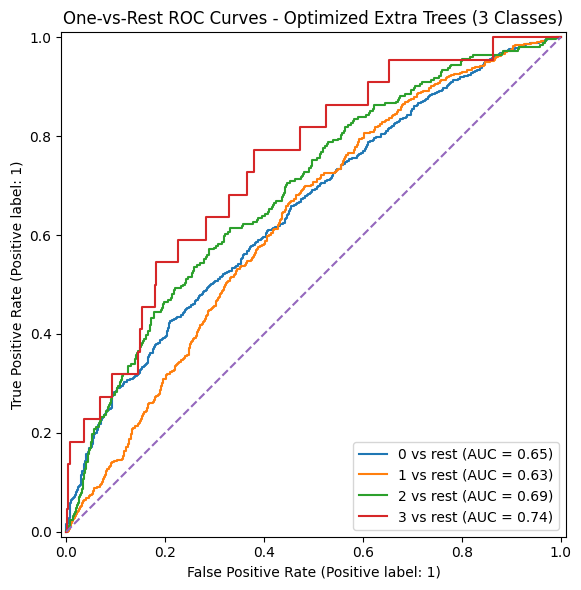

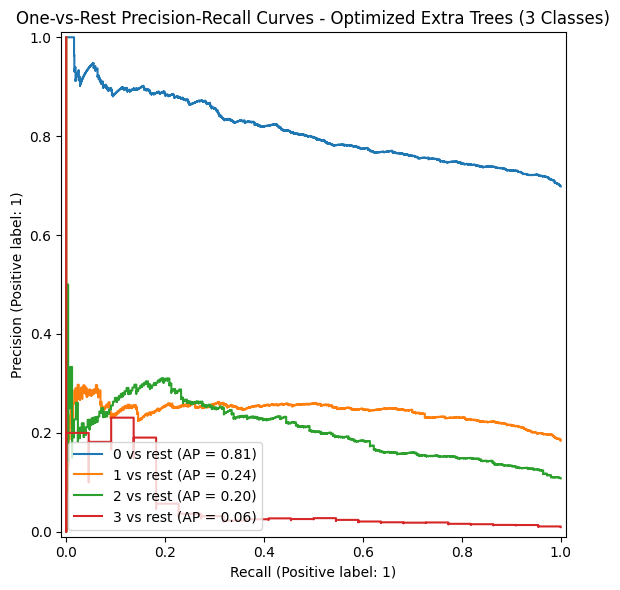


Classification report - Optimized Extra Trees (3 Classes)


,precision,recall,f1-score,support
0,0.776224,0.608034,0.681911,1643.000000
1,0.296703,0.249423,0.271016,433.000000
2,0.202128,0.448819,0.278729,254.000000
3,0.029197,0.181818,0.050314,22.000000
accuracy,0.520833,0.520833,0.520833,0.520833
macro avg,0.326063,0.372023,0.320493,2352.000000
weighted avg,0.618959,0.520833,0.556817,2352.000000


In [27]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_et = {
    # Numero di alberi decisionali estremamente casuali
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità degli alberi
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni per dividere un nodo
    'min_samples_split': [2, 5, 10],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # Numero minimo di campioni in una foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Strategia di selezione delle feature ad ogni split
    'max_features': ['sqrt', 'log2', None],
    
    # Bilanciamento dinamico basato sulla distribuzione bootstrap dei dati
    'class_weight': ['balanced', 'balanced_subsample']
}

# Modello base Extra Trees
et_base = ExtraTreesClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Extra Trees Hyperparameter Tuning...")

random_search_et = RandomizedSearchCV(
    estimator=et_base,
    param_distributions=param_dist_et,
    n_iter=50,                     # 50 combinazioni casuali nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi (senza alterazioni esterne)
random_search_et.fit(X_train, y_train)

# Estrazione del modello migliore
best_et = random_search_et.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_et.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_et.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Extra Trees Model on Test Set...")

# Lanciamo la valutazione passando direttamente l'estimatore ottimizzato
results, report_df = evaluate_classifier(
    model=best_et,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Extra Trees (3 Classes)",
    normalize_cm="true"
)

## 3 classes, imbalanced

In [25]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (5487, 32), Test size: (2352, 32)
Puoi lanciare la tua RandomizedSearch


Starting Extra Trees Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced'}
Best Balanced Accuracy Score (CV): 0.4801

Evaluating Best Extra Trees Model on Test Set...


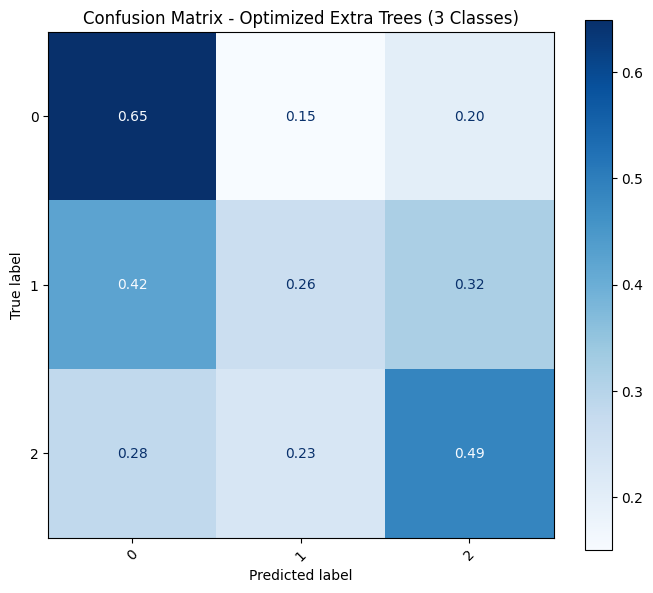

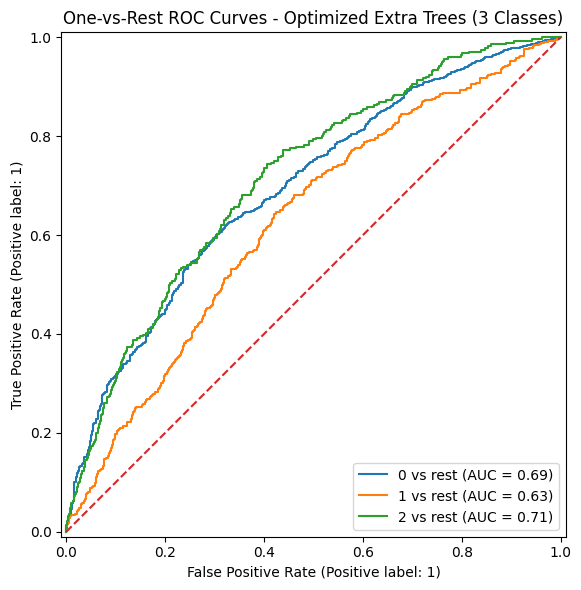

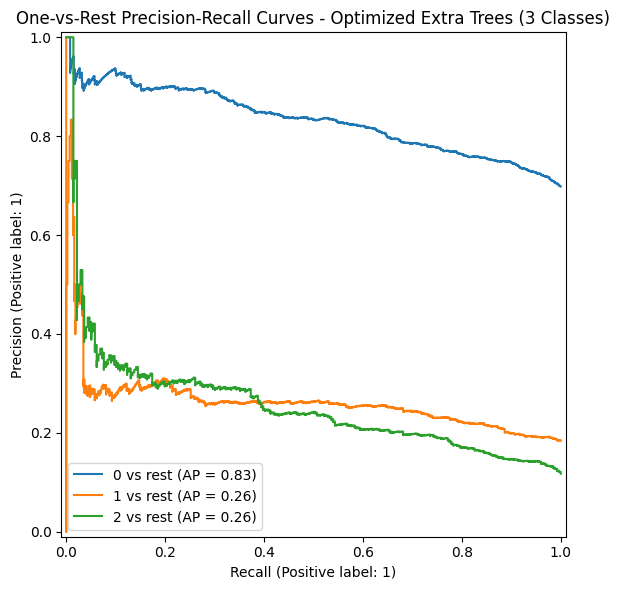


Classification report - Optimized Extra Trees (3 Classes)


,precision,recall,f1-score,support
0,0.803464,0.649422,0.718277,1643.000000
1,0.266509,0.260970,0.263711,433.000000
2,0.223333,0.485507,0.305936,276.000000
accuracy,0.558673,0.558673,0.558673,0.558673
macro avg,0.431102,0.465300,0.429308,2352.000000
weighted avg,0.636535,0.558673,0.586205,2352.000000


In [26]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_et = {
    # Numero di alberi decisionali estremamente casuali
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità degli alberi
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni per dividere un nodo
    'min_samples_split': [2, 5, 10],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # Numero minimo di campioni in una foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Strategia di selezione delle feature ad ogni split
    'max_features': ['sqrt', 'log2', None],
    
    # Bilanciamento dinamico basato sulla distribuzione bootstrap dei dati
    'class_weight': ['balanced', 'balanced_subsample']
}

# Modello base Extra Trees
et_base = ExtraTreesClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Extra Trees Hyperparameter Tuning...")

random_search_et = RandomizedSearchCV(
    estimator=et_base,
    param_distributions=param_dist_et,
    n_iter=50,                     # 50 combinazioni casuali nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi (senza alterazioni esterne)
random_search_et.fit(X_train, y_train)

# Estrazione del modello migliore
best_et = random_search_et.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_et.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_et.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Extra Trees Model on Test Set...")

# Lanciamo la valutazione passando direttamente l'estimatore ottimizzato
results, report_df = evaluate_classifier(
    model=best_et,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Extra Trees (3 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

In [16]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (5487, 32), Test size: (2352, 32)
Puoi lanciare la tua RandomizedSearch


Starting Scaled ADASYN + ENN + Extra Trees Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'et__n_estimators': 500, 'et__min_samples_split': 2, 'et__min_samples_leaf': 4, 'et__max_features': 'sqrt', 'et__max_depth': 10, 'et__criterion': 'entropy', 'et__class_weight': 'balanced', 'enn__n_neighbors': 5, 'enn__kind_sel': 'all', 'adasyn__n_neighbors': 5}
Best Balanced Accuracy Score (CV): 0.4891

Evaluating Best Hybrid Extra Trees Model on Test Set...


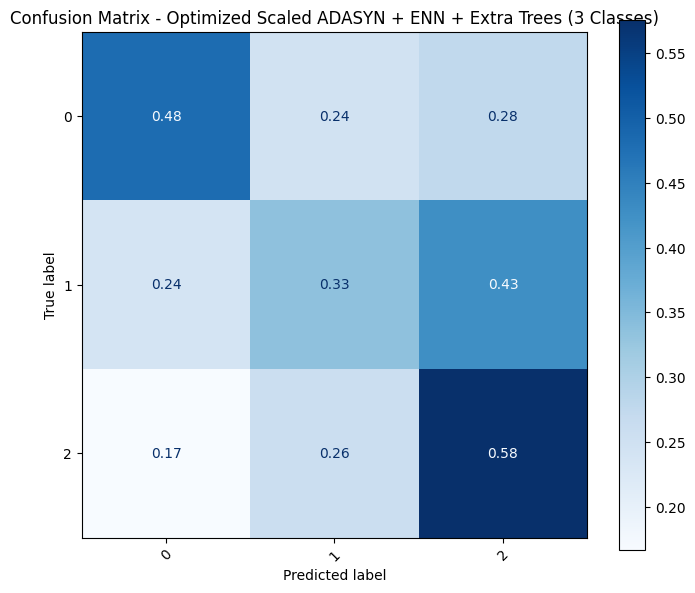

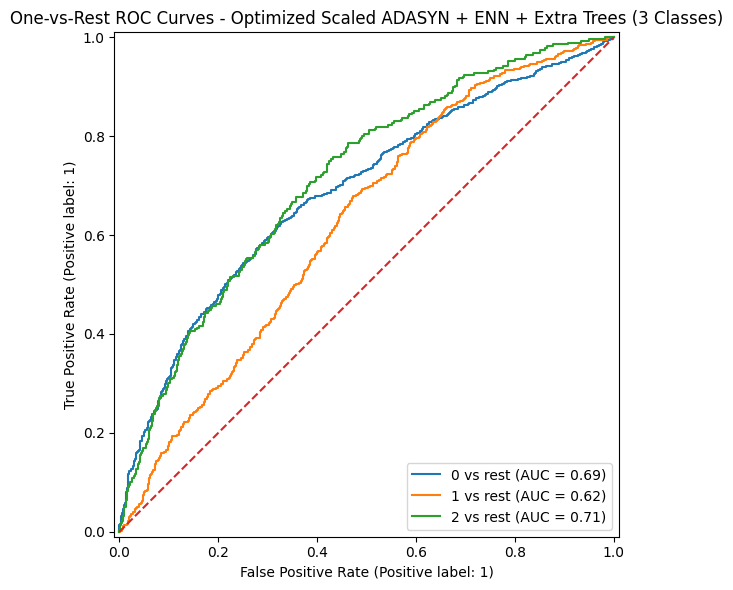

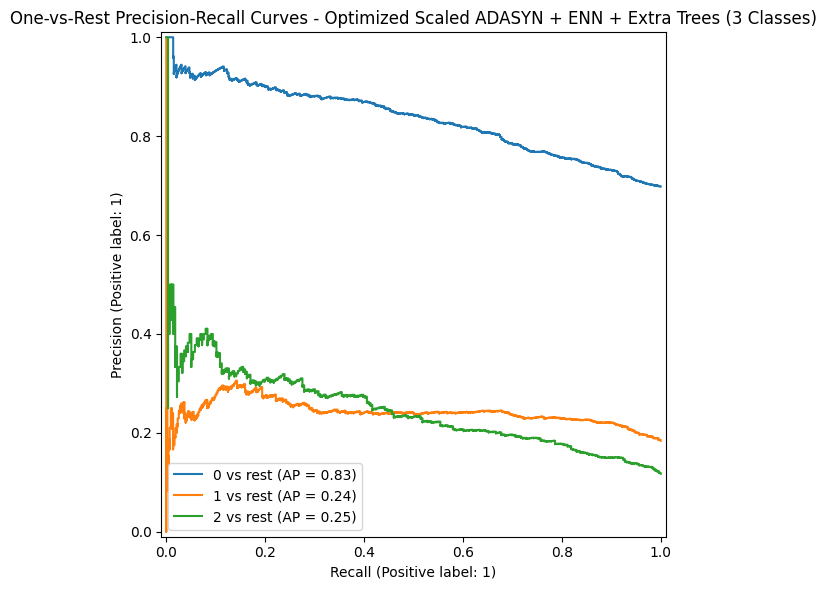


Classification report - Optimized Scaled ADASYN + ENN + Extra Trees (3 Classes)


,precision,recall,f1-score,support
0,0.841151,0.480219,0.611391,1643.000000
1,0.234628,0.334873,0.275928,433.000000
2,0.199749,0.576087,0.296642,276.000000
accuracy,0.464711,0.464711,0.464711,0.464711
macro avg,0.425176,0.463726,0.394653,2352.000000
weighted avg,0.654225,0.464711,0.512698,2352.000000


In [27]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler                   # Essenziale per le distanze geometriche (Adasyn/ENN)
from imblearn.over_sampling import ADASYN                          
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline              # Previene il Data Leakage

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_hybrid_et = {
    # Parametri ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], # 'all' per pulire i confini di tutte le macro-classi
    
    # Parametri dell'Extra Trees (notare il prefisso 'et__')
    'et__n_estimators': [100, 200, 300, 500],
    'et__max_depth': [None, 10, 20, 30, 40],
    'et__min_samples_split': [2, 5, 10],
    'et__criterion': ['gini', 'entropy'],
    'et__min_samples_leaf': [1, 2, 4],
    'et__max_features': ['sqrt', 'log2', None],
    'et__class_weight': ['balanced', 'balanced_subsample']
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE IBRIDA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base Extra Trees (n_jobs=-1 spostato qui per parallelizzare in sicurezza)
et_base = ExtraTreesClassifier(random_state=42, n_jobs=-1)

# Costruzione della pipeline sequenziale e protetta
pipeline_et_hybrid = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione per far calcolare bene le distanze ai K-NN
    ('adasyn', adasyn_sampler),   # Fase 2: Generazione campioni sintetici mirati
    ('enn', enn_sampler),         # Fase 3: Pulizia chirurgica delle sovrapposizioni e del rumore
    ('et', et_base)               # Fase 4: Classificazione ad alta randomizzazione
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled ADASYN + ENN + Extra Trees Hyperparameter Tuning...")

random_search_hybrid_et = RandomizedSearchCV(
    estimator=pipeline_et_hybrid,
    param_distributions=param_dist_hybrid_et,
    n_iter=50,                     # 50 combinazioni casuali nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione coerente con il problema di sbilanciamento
    n_jobs=1,                      # IMPERATIVO: 1 per evitare crash della memoria con joblib/imblearn
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi (senza alterazioni esterne)
random_search_hybrid_et.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_et = random_search_hybrid_et.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_et.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_et.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Hybrid Extra Trees Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_et,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled ADASYN + ENN + Extra Trees (3 Classes)",
    normalize_cm="true"
)

### Feature Importance

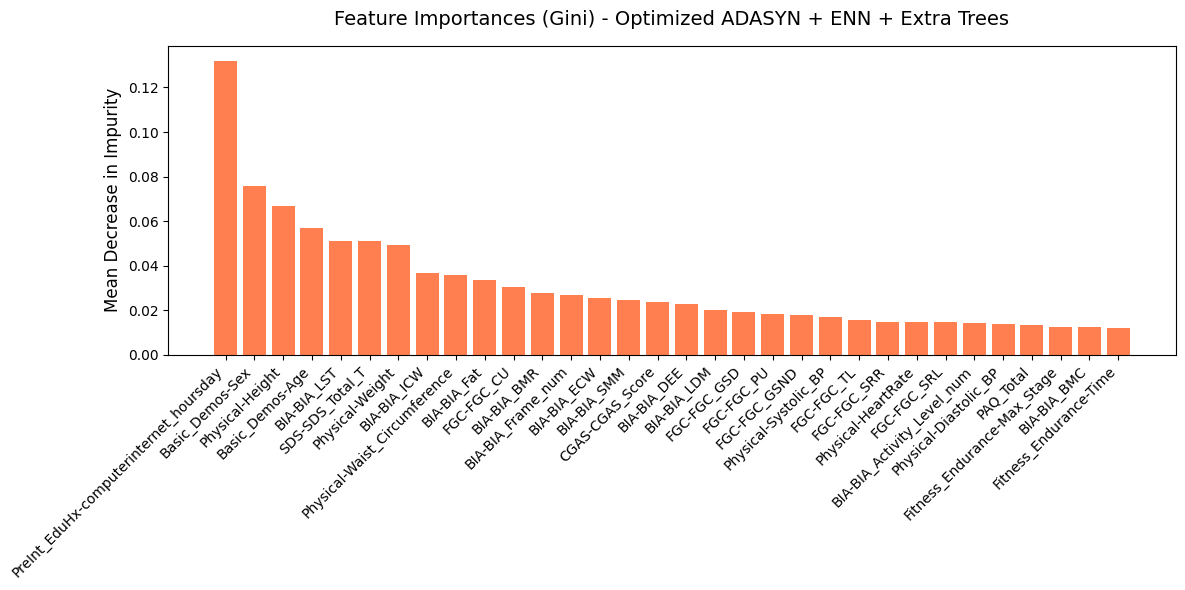

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Estrazione del modello
et_model = best_pipeline_et.named_steps['et']
importances = et_model.feature_importances_
feature_names = X_train.columns

# 2. Ordinamento
sorted_indices = np.argsort(importances)[::-1]

# 3. Plot formatato per la tesi
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[sorted_indices], align='center', color='coral')
plt.xticks(range(len(importances)), feature_names[sorted_indices], rotation=45, ha='right', fontsize=10)
plt.title("Feature Importances (Gini) - Optimized ADASYN + ENN + Extra Trees", fontsize=14, pad=15)
plt.ylabel("Mean Decrease in Impurity", fontsize=12)
plt.tight_layout()
plt.show()

### Permutation Importance

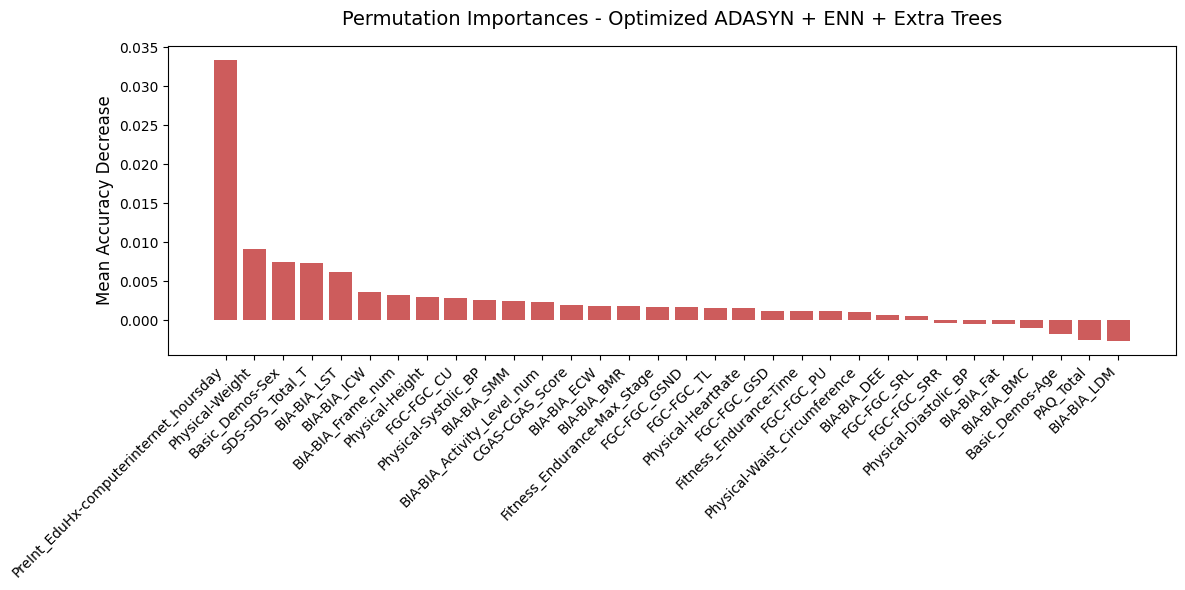

In [29]:
from sklearn.inspection import permutation_importance

# 1. Calcolo della permutazione sull'intera pipeline (protezione da scala e leakage)
perm_importance = permutation_importance(
    best_pipeline_et, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

# 2. Ordinamento
perm_sorted_indices = np.argsort(perm_importance.importances_mean)[::-1]

# 3. Plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(perm_importance.importances_mean)), perm_importance.importances_mean[perm_sorted_indices], align='center', color='indianred')
plt.xticks(range(len(perm_importance.importances_mean)), feature_names[perm_sorted_indices], rotation=45, ha='right', fontsize=10)
plt.title("Permutation Importances - Optimized ADASYN + ENN + Extra Trees", fontsize=14, pad=15)
plt.ylabel("Mean Accuracy Decrease", fontsize=12)
plt.tight_layout()
plt.show()

### First Tree Root

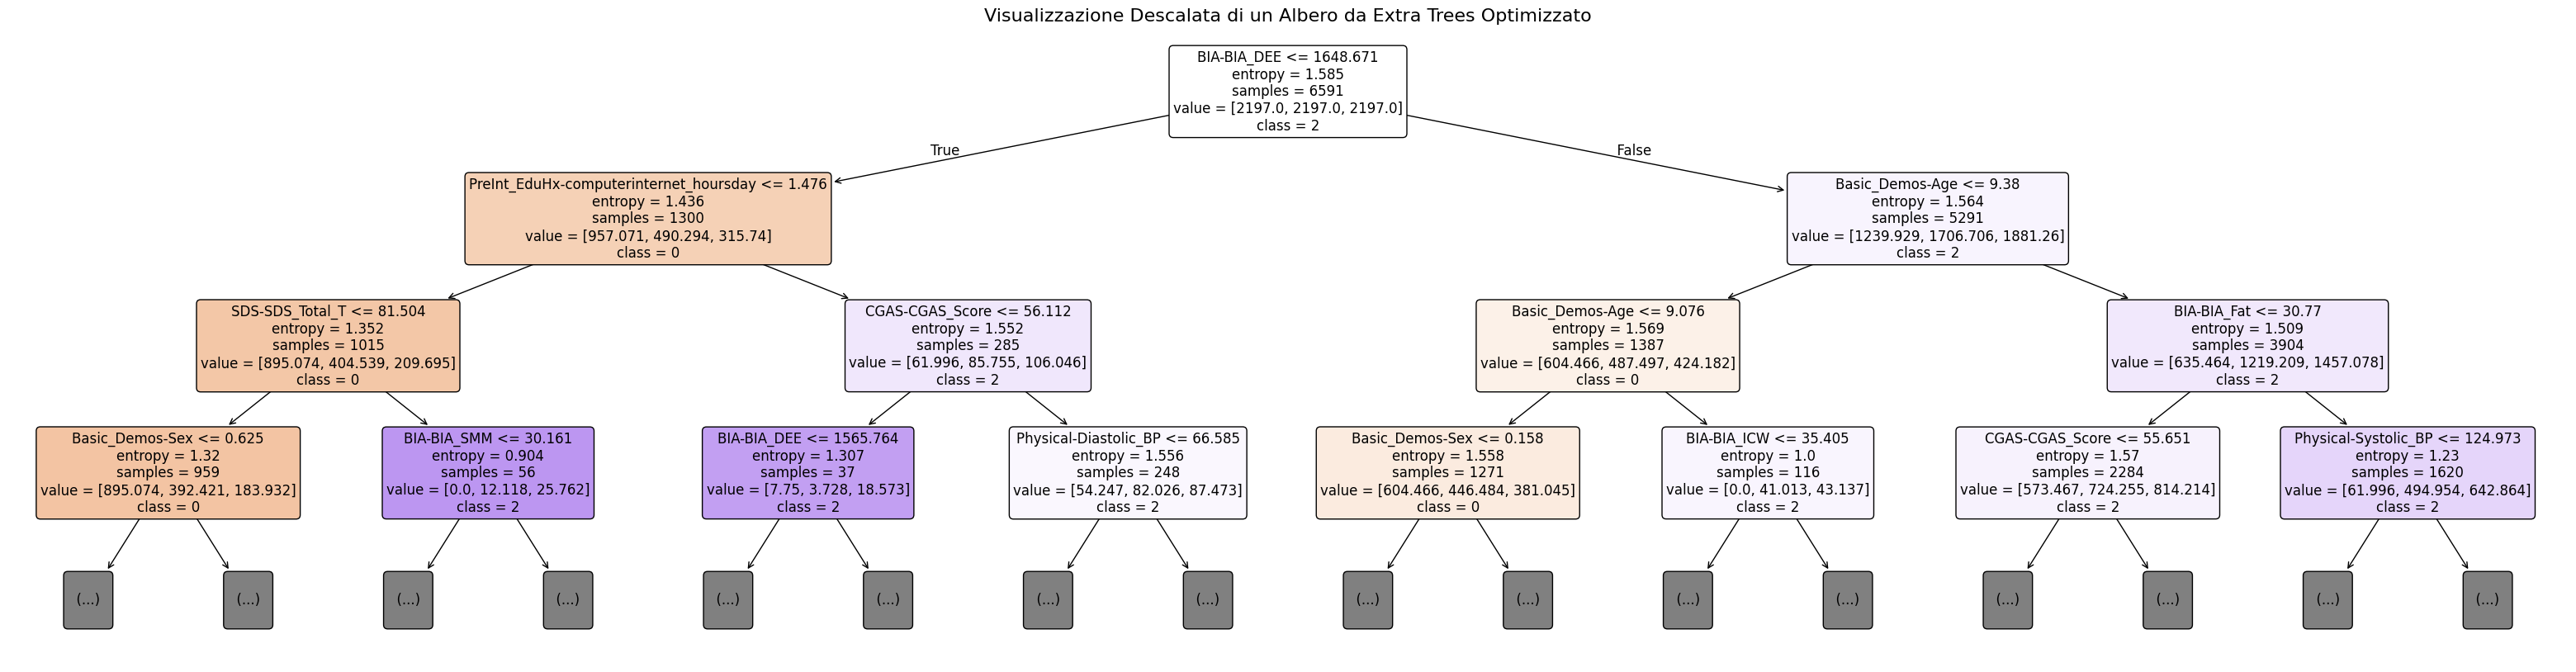

In [30]:
import copy
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Estrazione dei componenti dalla pipeline Extra Trees
scaler = best_pipeline_et.named_steps['scaler']
et_model = best_pipeline_et.named_steps['et']

# 2. Copia profonda del primo albero estremamente casuale
tree_to_plot = copy.deepcopy(et_model.estimators_[0])

# 3. Ripristino dei valori originali sulle soglie di taglio
means = scaler.mean_
scales = scaler.scale_

for i, feature_index in enumerate(tree_to_plot.tree_.feature):
    if feature_index != -2: # Escludiamo le foglie
        tree_to_plot.tree_.threshold[i] = (tree_to_plot.tree_.threshold[i] * scales[feature_index]) + means[feature_index]

# 4. Plot dell'albero de-scalato
plt.figure(figsize=(40, 10))
plot_tree(
    tree_to_plot, 
    filled=True, 
    feature_names=X_train.columns.tolist(),
    class_names=['0', '1', '2'], # Regola in ['0', '1', '2', '3'] se usi 4 classi
    max_depth=3, 
    fontsize=12, 
    rounded=True
)
plt.title("Visualizzazione Descalata di un Albero da Extra Trees Optimizzato", fontsize=16)
plt.show()

# 3. **Bagging**

## DecisionTree

## 4 classes, imbalanced

Starting Bagging + Decision Tree Hyperparameter Tuning...
This setup will run exponentially faster than SVC.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'max_samples': 0.9, 'max_features': 1.0, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 4, 'estimator__max_depth': 10, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.3402

Evaluating Best Bagging + Decision Tree Model on Test Set...


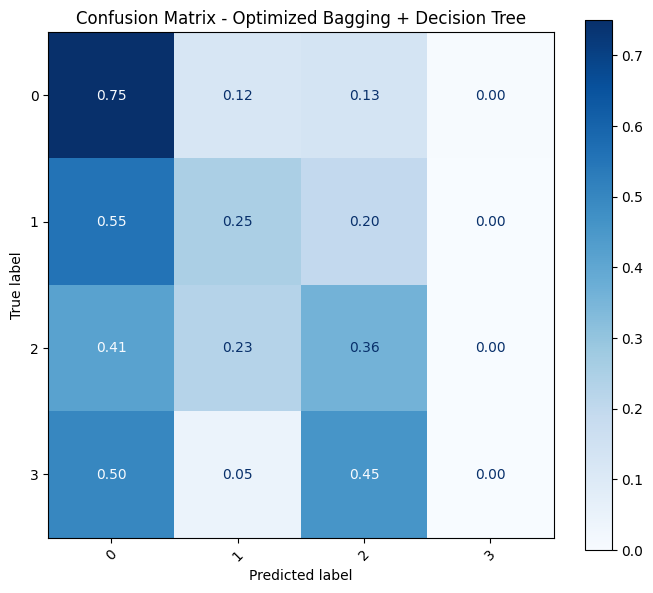

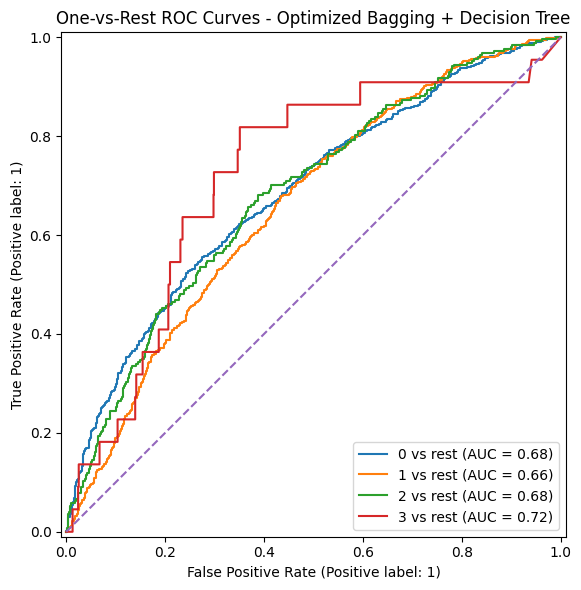

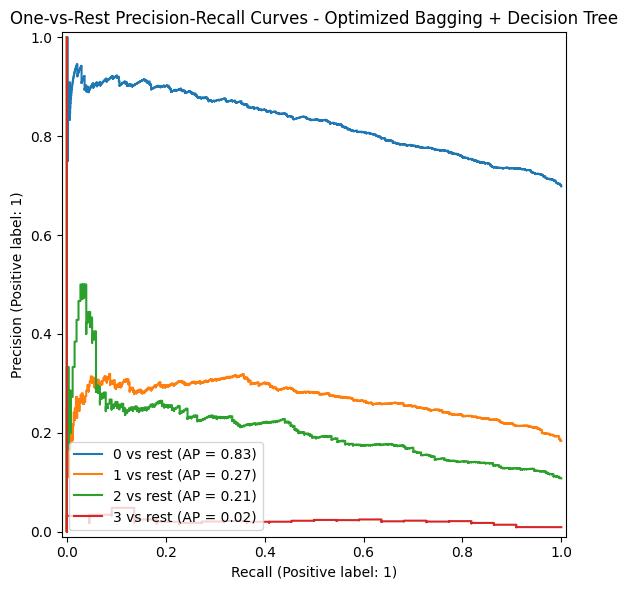


Classification report - Optimized Bagging + Decision Tree


,precision,recall,f1-score,support
0,0.775960,0.750456,0.762995,1643.000000
1,0.300000,0.249423,0.272383,433.000000
2,0.228643,0.358268,0.279141,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.608844,0.608844,0.608844,0.608844
macro avg,0.326151,0.339537,0.328630,2352.000000
weighted avg,0.621972,0.608844,0.613284,2352.000000


In [36]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per configurare l'albero di base
param_dist_bagging_dt = {
    # Parametri del Bagging
    'n_estimators': [50, 100, 200, 300],       # Ora possiamo permetterci centinaia di alberi!
    'max_samples': [0.5, 0.7, 0.9, 1.0],       # Quanti campioni clonare per albero
    'max_features': [0.5, 0.7, 0.9, 1.0],      # Quante feature dare a ogni albero
    
    # Parametri del Decision Tree sottostante
    'estimator__max_depth': [None, 10, 20, 30, 40],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Configuriamp il Decision Tree di base con la gestione dello sbilanciamento
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier inserendo l'albero appena creato
bagging_dt_model = BaggingClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Bagging + Decision Tree Hyperparameter Tuning...")
print("This setup will run exponentially faster than SVC.")

random_search_bag_dt = RandomizedSearchCV(
    estimator=bagging_dt_model,
    param_distributions=param_dist_bagging_dt,
    n_iter=40,                     # Esploriamo 40 combinazioni (molto più approfondito)
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 classi
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla classe minoritaria
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_bag_dt.fit(X_train, y_train)

# Estrazione del modello migliore
best_bagging_dt = random_search_bag_dt.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_bag_dt.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_bag_dt.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Bagging + Decision Tree Model on Test Set...")

# Inviamo il modello finale alla tua funzione per generare metriche e grafici
results, report_df = evaluate_classifier(
    model=best_bagging_dt,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Optimized Bagging + Decision Tree",
    normalize_cm="true"
)

## 3 classes, imbalanced

In [22]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (5487, 32), Test size: (2352, 32)
Puoi lanciare la tua RandomizedSearch


Starting Bagging + Decision Tree Hyperparameter Tuning...
This setup will run exponentially faster than SVC.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 300, 'max_samples': 1.0, 'max_features': 0.5, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 4, 'estimator__max_depth': 10, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.4551

Evaluating Best Bagging + Decision Tree Model on Test Set...


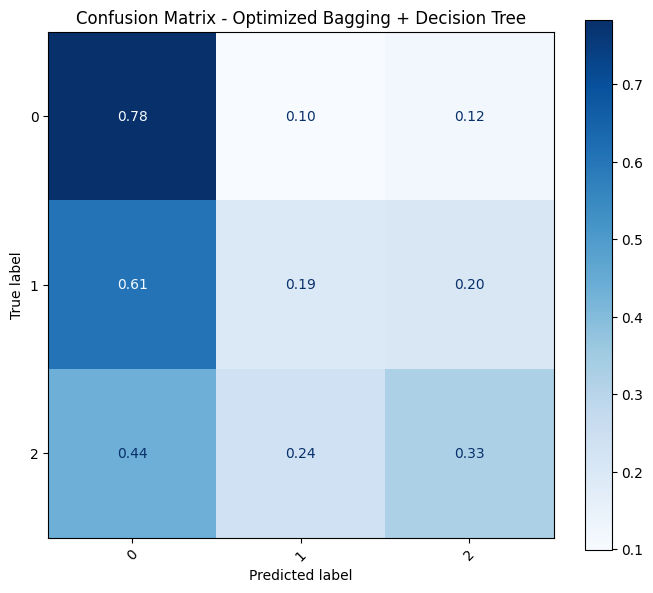

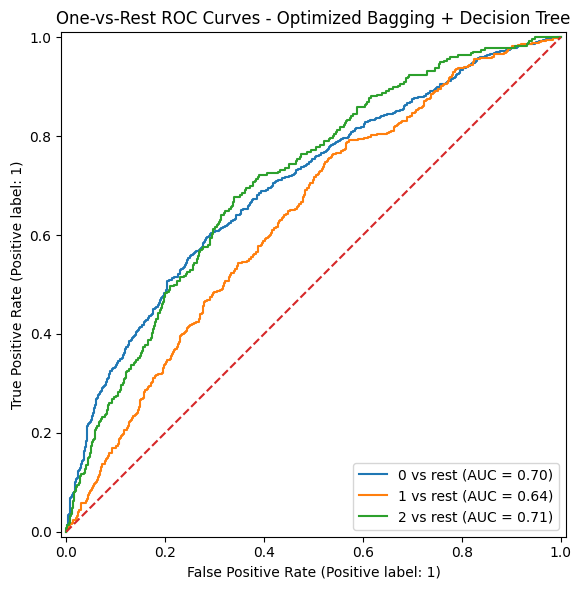

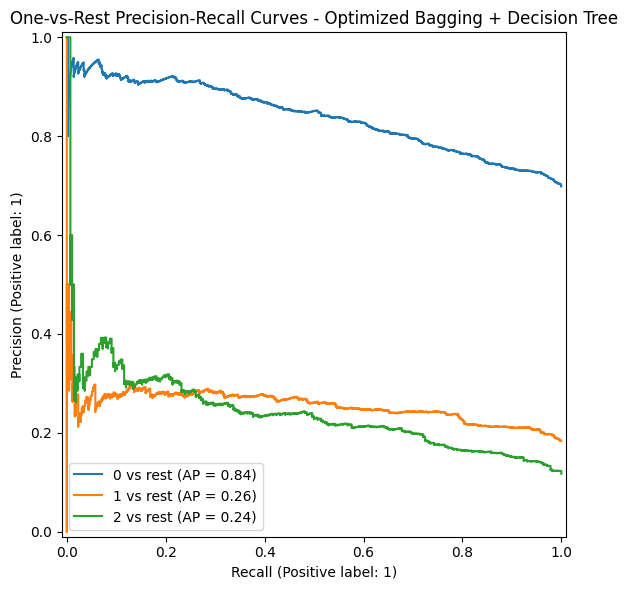


Classification report - Optimized Bagging + Decision Tree


,precision,recall,f1-score,support
0,0.770659,0.783323,0.776939,1643.000000
1,0.269231,0.193995,0.225503,433.000000
2,0.243243,0.326087,0.278638,276.000000
accuracy,0.621173,0.621173,0.621173,0.621173
macro avg,0.427711,0.434469,0.427027,2352.000000
weighted avg,0.616456,0.621173,0.616947,2352.000000


In [23]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per configurare l'albero di base
param_dist_bagging_dt = {
    # Parametri del Bagging
    'n_estimators': [50, 100, 200, 300],       # Ora possiamo permetterci centinaia di alberi!
    'max_samples': [0.5, 0.7, 0.9, 1.0],       # Quanti campioni clonare per albero
    'max_features': [0.5, 0.7, 0.9, 1.0],      # Quante feature dare a ogni albero
    
    # Parametri del Decision Tree sottostante
    'estimator__max_depth': [None, 10, 20, 30, 40],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Configuriamp il Decision Tree di base con la gestione dello sbilanciamento
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier inserendo l'albero appena creato
bagging_dt_model = BaggingClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Bagging + Decision Tree Hyperparameter Tuning...")
print("This setup will run exponentially faster than SVC.")

random_search_bag_dt = RandomizedSearchCV(
    estimator=bagging_dt_model,
    param_distributions=param_dist_bagging_dt,
    n_iter=40,                     # Esploriamo 40 combinazioni (molto più approfondito)
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 classi
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla classe minoritaria
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_bag_dt.fit(X_train, y_train)

# Estrazione del modello migliore
best_bagging_dt = random_search_bag_dt.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_bag_dt.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_bag_dt.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Bagging + Decision Tree Model on Test Set...")

# Inviamo il modello finale alla tua funzione per generare metriche e grafici
results, report_df = evaluate_classifier(
    model=best_bagging_dt,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Optimized Bagging + Decision Tree",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

Starting Scaled ADASYN + ENN + Bagging Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'enn__n_neighbors': 5, 'enn__kind_sel': 'mode', 'bag__n_estimators': 200, 'bag__max_samples': 1.0, 'bag__max_features': 0.5, 'bag__estimator__min_samples_split': 10, 'bag__estimator__min_samples_leaf': 4, 'bag__estimator__max_depth': 10, 'bag__estimator__criterion': 'entropy', 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.4885

Evaluating Best Hybrid Bagging Model on Test Set...


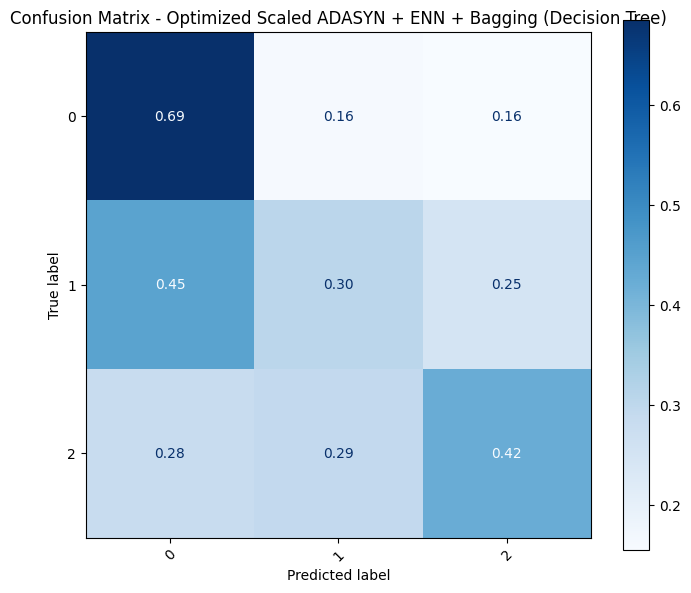

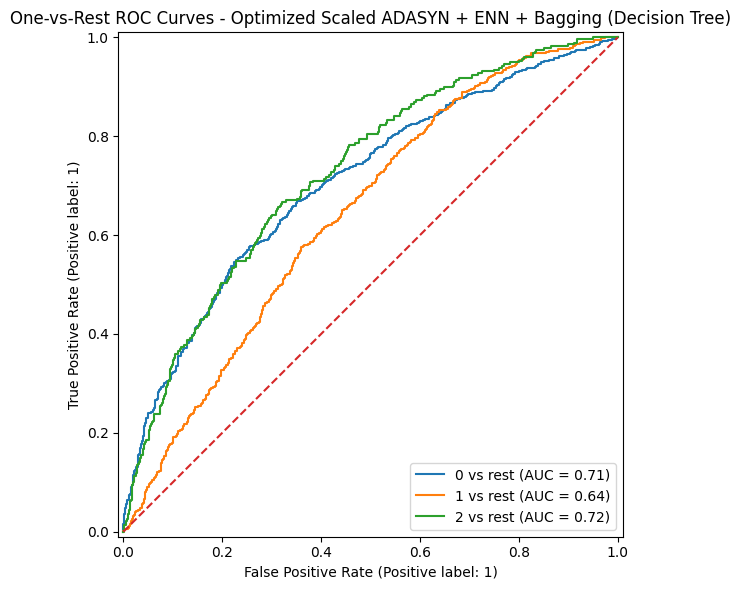

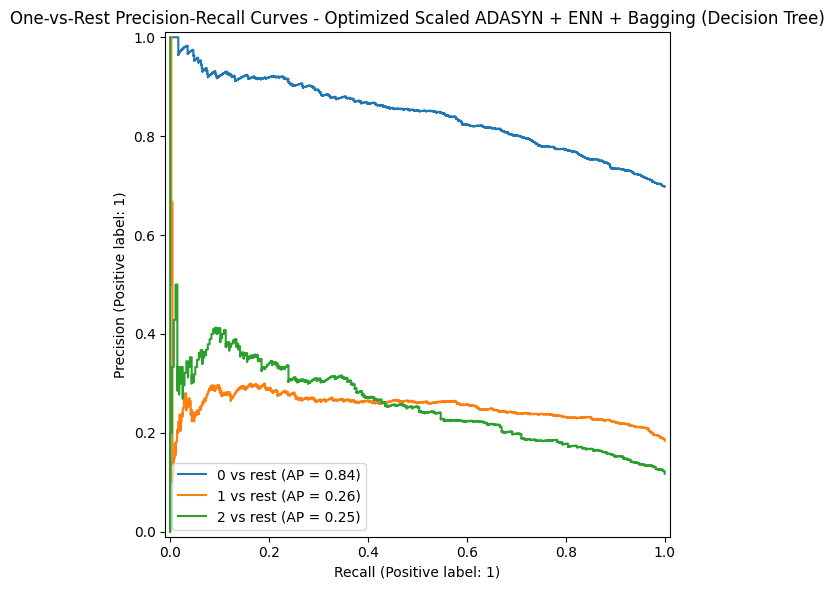


Classification report - Optimized Scaled ADASYN + ENN + Bagging (Decision Tree)


,precision,recall,f1-score,support
0,0.806013,0.685332,0.740789,1643.000000
1,0.277895,0.304850,0.290749,433.000000
2,0.243750,0.423913,0.309524,276.000000
accuracy,0.584609,0.584609,0.584609,0.584609
macro avg,0.442553,0.471365,0.447021,2352.000000
weighted avg,0.642807,0.584609,0.607330,2352.000000


In [24]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler                   # Essenziale per le distanze geometriche
from imblearn.over_sampling import ADASYN                          
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline              # Previene il Data Leakage

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_hybrid_bag = {
    # Parametri ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], 
    
    # Parametri del Bagging (notare il prefisso 'bag__')
    'bag__n_estimators': [50, 100, 200, 300], # Numero di alberi nel bagging
    'bag__max_samples': [0.5, 0.7, 0.9, 1.0], # Percentuale di campioni da clonare per ogni albero
    'bag__max_features': [0.5, 0.7, 0.9, 1.0], # Percentuale di feature da dare a ogni albero
    
    # Parametri del Decision Tree sottostante (notare il doppio prefisso 'bag__estimator__')
    'bag__estimator__max_depth': [None, 10, 20, 30, 40],
    'bag__estimator__criterion': ['gini', 'entropy'],
    'bag__estimator__min_samples_split': [2, 5, 10],
    'bag__estimator__min_samples_leaf': [1, 2, 4]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE IBRIDA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Configuriamo il Decision Tree di base con la gestione dello sbilanciamento
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier (n_jobs=-1 spostato qui per parallelizzare in sicurezza)
bagging_dt_model = BaggingClassifier(estimator=dt_base, random_state=42, n_jobs=-1)

# Costruzione della pipeline sequenziale e protetta
pipeline_bag_hybrid = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione per il calcolo delle distanze euclidee
    ('adasyn', adasyn_sampler),   # Fase 2: Generazione campioni sintetici
    ('enn', enn_sampler),         # Fase 3: Pulizia delle sovrapposizioni e dei confini
    ('bag', bagging_dt_model)     # Fase 4: Classificazione tramite Bagging Ensemble
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled ADASYN + ENN + Bagging Hyperparameter Tuning...")

random_search_hybrid_bag = RandomizedSearchCV(
    estimator=pipeline_bag_hybrid,
    param_distributions=param_dist_hybrid_bag,
    n_iter=40,                     # Esploriamo 40 combinazioni nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=1,                      # IMPERATIVO: 1 per evitare crash della memoria con joblib/imblearn
    random_state=42,
    verbose=1
)

# Fit sui dati originali sbilanciati
random_search_hybrid_bag.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_bag = random_search_hybrid_bag.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_bag.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_bag.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Hybrid Bagging Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_bag,
    X_test=X_test,       # Test set reale sbilanciato (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled ADASYN + ENN + Bagging (Decision Tree)",
    normalize_cm="true"
)

## 3 classes, balanced (BalancedBaggingClassifier)

Starting Scaled BalancedBagging + Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'bag__n_estimators': 300, 'bag__max_samples': 0.9, 'bag__max_features': 1.0, 'bag__estimator__min_samples_split': 2, 'bag__estimator__min_samples_leaf': 4, 'bag__estimator__max_depth': 30, 'bag__estimator__criterion': 'entropy'}
Best Balanced Accuracy Score (CV): 0.5062

Evaluating Best Balanced Bagging + DT Model on Test Set...


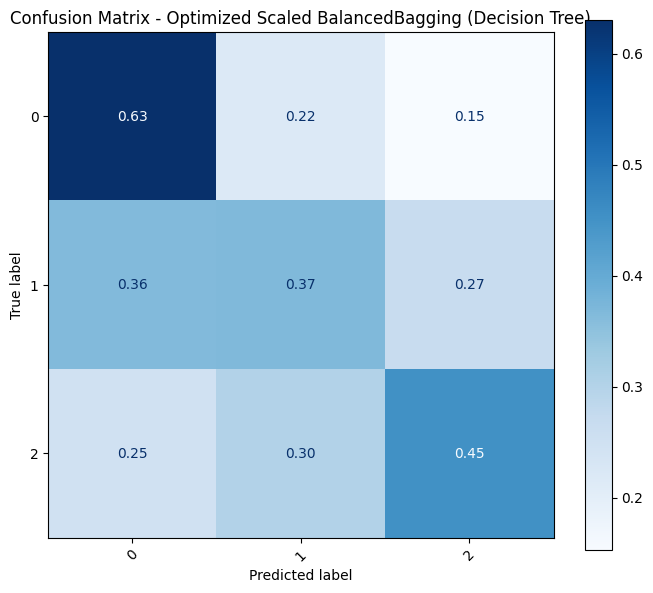

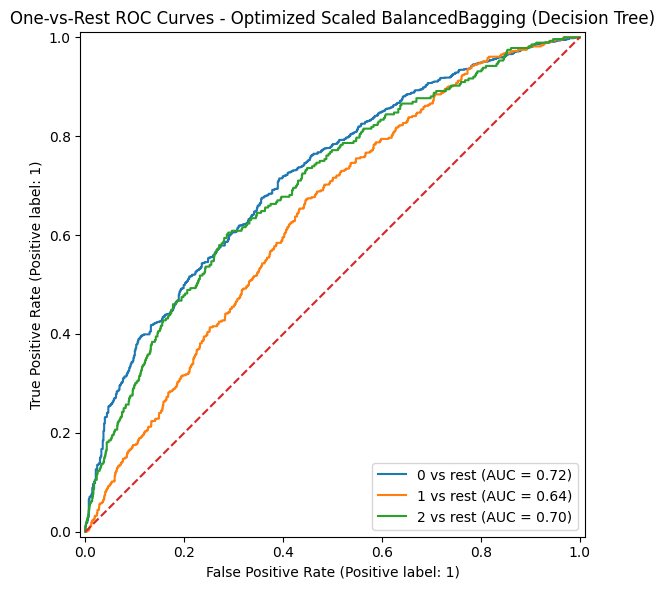

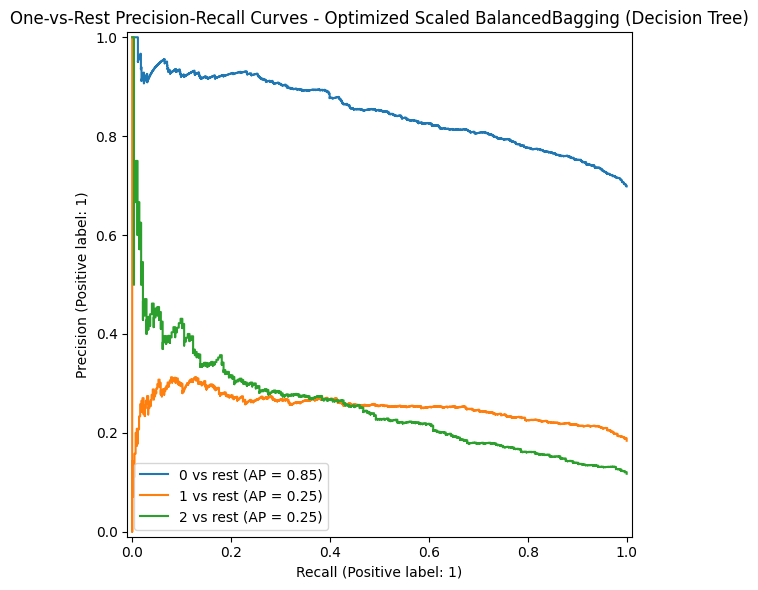


Classification report - Optimized Scaled BalancedBagging (Decision Tree)


,precision,recall,f1-score,support
0,0.820919,0.630554,0.713253,1643.000000
1,0.265886,0.367206,0.308438,433.000000
2,0.254065,0.452899,0.325521,276.000000
accuracy,0.561224,0.561224,0.561224,0.561224
macro avg,0.446957,0.483553,0.449071,2352.000000
weighted avg,0.652220,0.561224,0.593228,2352.000000


In [12]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_balanced_bag_dt = {
    # Parametri del BalancedBaggingClassifier (notare il prefisso 'bag__')
    'bag__n_estimators': [50, 100, 200, 300], # Numero di alberi nell'ensemble
    'bag__max_samples': [0.5, 0.7, 0.9, 1.0], # Quanti campioni clonare per ogni albero
    'bag__max_features': [0.5, 0.7, 0.9, 1.0], # Quante feature assegnare a ogni albero
    
    # Parametri del Decision Tree sottostante (notare il doppio prefisso 'bag__estimator__')
    'bag__estimator__max_depth': [None, 10, 20, 30, 40],
    'bag__estimator__criterion': ['gini', 'entropy'],
    'bag__estimator__min_samples_split': [2, 5, 10],
    'bag__estimator__min_samples_leaf': [1, 2, 4]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE
# =========================================================================
# Configuriamo il Decision Tree di base con la gestione interna dei pesi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BalancedBaggingClassifier
# Esegue un down-sampling della classe maggioritaria su ogni singolo bootstrap
balanced_bagging_model = BalancedBaggingClassifier(
    estimator=dt_base, 
    sampling_strategy='auto',
    random_state=42, 
    n_jobs=-1
)

# Costruzione della pipeline sequenziale protetta da Data Leakage
pipeline_balanced_bag_dt = ImbPipeline([
    ('scaler', StandardScaler()),            # Fase 1: Standardizzazione (opzionale per DT, ottima per l'ensemble)
    ('bag', balanced_bagging_model)          # Fase 2: Bilanciamento bootstrap e classificazione
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled BalancedBagging + Decision Tree Hyperparameter Tuning...")

random_search_balanced_bag_dt = RandomizedSearchCV(
    estimator=pipeline_balanced_bag_dt,
    param_distributions=param_dist_balanced_bag_dt,
    n_iter=40,                        # Esploriamo 40 combinazioni nello spazio dei parametri
    cv=5,                             # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',      # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=1,                         # 1 per evitare conflitti di parallelismo (n_jobs=-1 è già dentro il bagging)
    random_state=42,
    verbose=1
)

# Fit sui dati originali sbilanciati a 3 classi
random_search_balanced_bag_dt.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_bag_dt = random_search_balanced_bag_dt.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_balanced_bag_dt.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_balanced_bag_dt.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Balanced Bagging + DT Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_bag_dt,
    X_test=X_test,          # Test set reale sbilanciato (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled BalancedBagging (Decision Tree)",
    normalize_cm="true"
)

## Perceptron

## 4 classes imbalanced

Starting Bagging + Perceptron Hyperparameter Tuning...
This setup will parallelize efficient linear boundaries across the ensemble.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 50, 'max_samples': 0.7, 'max_features': 0.9, 'estimator__penalty': None, 'estimator__max_iter': 2000, 'estimator__eta0': 1.0, 'estimator__alpha': 0.001}
Best Balanced Accuracy Score (CV): 0.2972

Evaluating Best Bagging + Perceptron Model on Test Set...


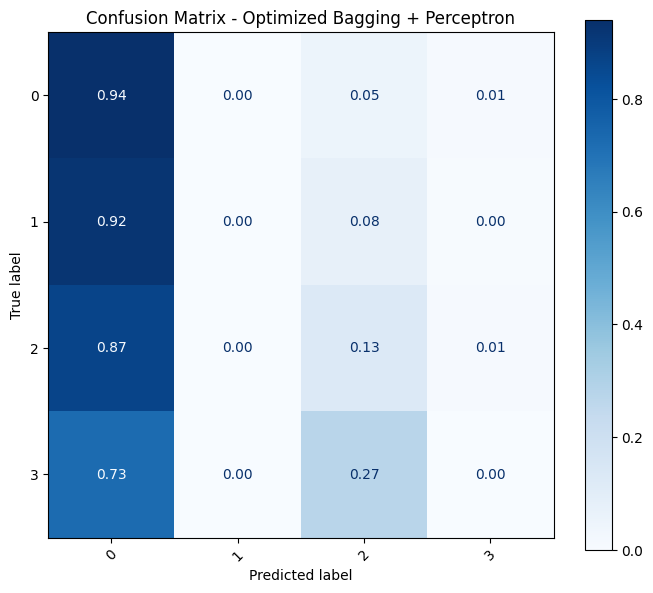

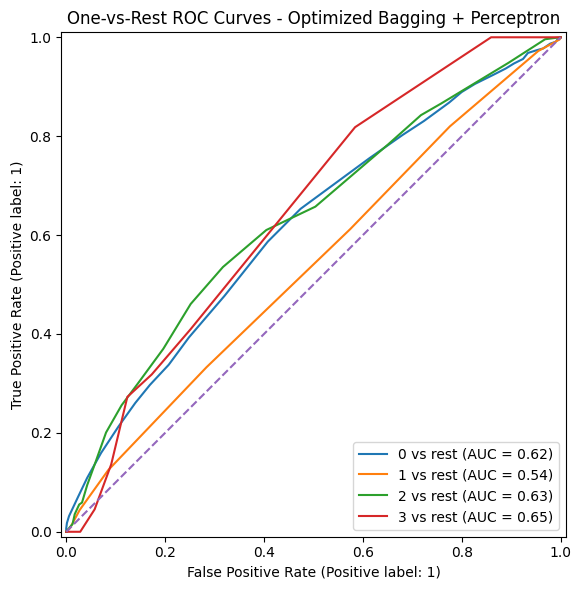

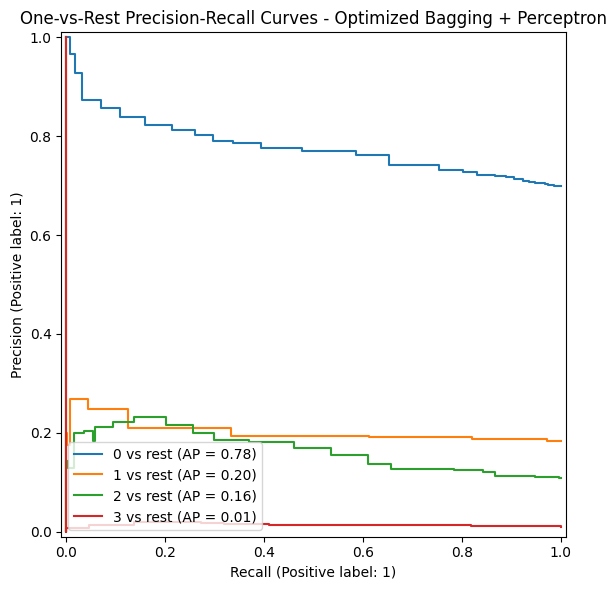


Classification report - Optimized Bagging + Perceptron


,precision,recall,f1-score,support
0,0.709041,0.940353,0.808477,1643.000000
1,0.000000,0.000000,0.000000,433.000000
2,0.207792,0.125984,0.156863,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.670493,0.670493,0.670493,0.670493
macro avg,0.229208,0.266584,0.241335,2352.000000
weighted avg,0.517744,0.670493,0.581705,2352.000000


In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV
from evaluate_classifier import evaluate_classifier

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per configurare il Perceptron di base
param_dist_bagging_perceptron = {
    # Parametri del Bagging
    'n_estimators': [50, 100, 200, 300],       # Numero di Perceptron nell'ensemble
    'max_samples': [0.5, 0.7, 0.9, 1.0],       # Quanti campioni clonare per ogni Perceptron
    'max_features': [0.5, 0.7, 0.9, 1.0],      # Quante feature assegnare a ogni Perceptron
    
    # Parametri del Perceptron sottostante
    'estimator__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'estimator__penalty': ['l2', 'l1', 'elasticnet', None],
    'estimator__max_iter': [1000, 2000],
    'estimator__eta0': [0.1, 0.5, 1.0, 2.0]
}

# Configuriamo il Perceptron di base con la gestione dello sbilanciamento
# Nota: Usiamo class_weight='balanced' per proteggere le classi minoritarie
perceptron_base = Perceptron(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier inserendo il Perceptron appena creato
bagging_perceptron_model = BaggingClassifier(estimator=perceptron_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Bagging + Perceptron Hyperparameter Tuning...")
print("This setup will parallelize efficient linear boundaries across the ensemble.")

random_search_bag_perc = RandomizedSearchCV(
    estimator=bagging_perceptron_model,
    param_distributions=param_dist_bagging_perceptron,
    n_iter=40,                     # Esploriamo 40 combinazioni differenti
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati a 3 classi sbilanciati
# Assicurati che y_train e X_train siano quelli relativi allo scenario a 3 classi
random_search_bag_perc.fit(X_train, y_train)

# Estrazione del modello migliore
best_bagging_perceptron = random_search_bag_perc.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_bag_perc.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_bag_perc.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Bagging + Perceptron Model on Test Set...")

# Inviamo il modello finale alla tua funzione per generare metriche e grafici
results, report_df = evaluate_classifier(
    model=best_bagging_perceptron,
    X_test=X_test,       # Test set reale (ricordati di usare il target a 3 classi coerente)
    y_test=y_test,
    model_name="Optimized Bagging + Perceptron",
    normalize_cm="true"
)

## 3 classes, imbalanced

In [10]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (5487, 32), Test size: (2352, 32)
Puoi lanciare la tua RandomizedSearch


Starting Bagging + Perceptron Hyperparameter Tuning...
This setup will run exponentially faster than SVC.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 300, 'max_samples': 0.5, 'max_features': 1.0, 'estimator__penalty': None, 'estimator__max_iter': 1000, 'estimator__eta0': 1.0, 'estimator__alpha': 0.0001}
Best Balanced Accuracy Score (CV): 0.3348

Evaluating Best Bagging + Perceptron Model on Test Set...


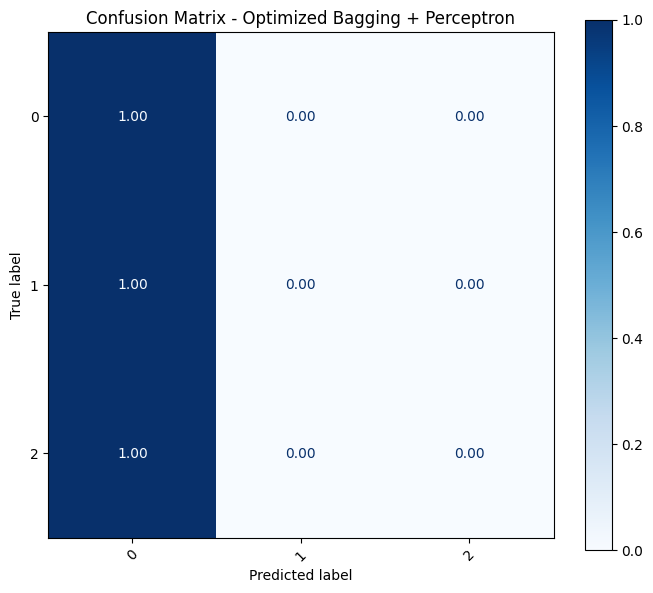

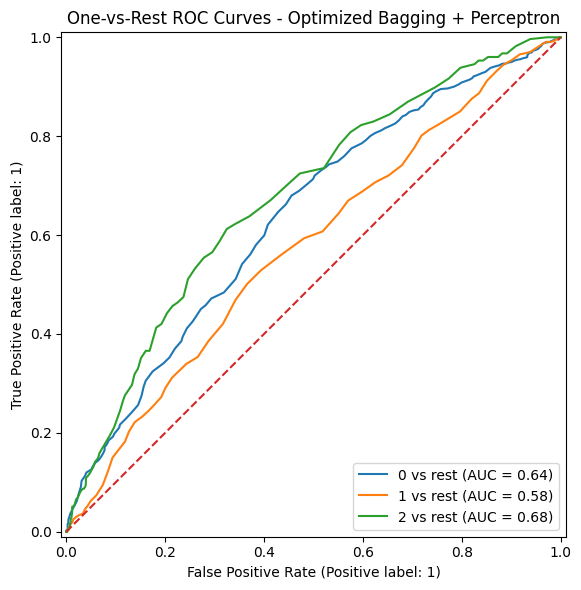

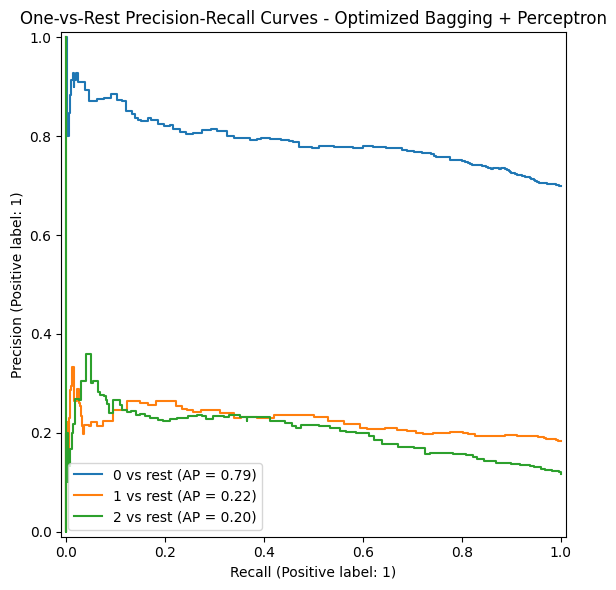


Classification report - Optimized Bagging + Perceptron


,precision,recall,f1-score,support
0,0.698298,0.998783,0.821938,1643.000000
1,0.000000,0.000000,0.000000,433.000000
2,0.000000,0.000000,0.000000,276.000000
accuracy,0.697704,0.697704,0.697704,0.697704
macro avg,0.232766,0.332928,0.273979,2352.000000
weighted avg,0.487799,0.697704,0.574169,2352.000000


In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per configurare il Perceptron di base
param_dist_bagging_perceptron = {
    # Parametri del Bagging
    'n_estimators': [50, 100, 200, 300],       # Numero di Perceptron nell'ensemble
    'max_samples': [0.5, 0.7, 0.9, 1.0],       # Quanti campioni clonare per ogni Perceptron
    'max_features': [0.5, 0.7, 0.9, 1.0],      # Quante feature assegnare a ogni Perceptron
    
    # Parametri del Perceptron sottostante
    'estimator__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'estimator__penalty': ['l2', 'l1', 'elasticnet', None],
    'estimator__max_iter': [1000, 2000],
    'estimator__eta0': [0.1, 0.5, 1.0, 2.0]
}

# Configuriamp il Perceptron di base
perceptron_base = Perceptron(random_state=42)

# Istanziamo il BaggingClassifier inserendo il Perceptron appena creato
bagging_perceptron_model = BaggingClassifier(estimator=perceptron_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Bagging + Perceptron Hyperparameter Tuning...")
print("This setup will run exponentially faster than SVC.")

random_search_bag_perceptron = RandomizedSearchCV(
    estimator=bagging_perceptron_model,
    param_distributions=param_dist_bagging_perceptron,
    n_iter=40,                     # Esploriamo 40 combinazioni (molto più approfondito)
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 classi
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla classe minoritaria
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_bag_perceptron.fit(X_train, y_train)

# Estrazione del modello migliore
best_bagging_perceptron = random_search_bag_perceptron.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_bag_perceptron.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_bag_perceptron.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Bagging + Perceptron Model on Test Set...")

# Inviamo il modello finale alla tua funzione per generare metriche e grafici
results, report_df = evaluate_classifier(
    model=best_bagging_perceptron,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized Bagging + Perceptron",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn +ENN)

Starting Scaled ADASYN + ENN + Bagging (Perceptron) Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'enn__n_neighbors': 3, 'enn__kind_sel': 'mode', 'bag__n_estimators': 200, 'bag__max_samples': 0.5, 'bag__max_features': 0.9, 'bag__estimator__penalty': 'elasticnet', 'bag__estimator__max_iter': 1000, 'bag__estimator__eta0': 0.1, 'bag__estimator__alpha': 0.0001, 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.4691

Evaluating Best Hybrid Bagging + Perceptron Model on Test Set...


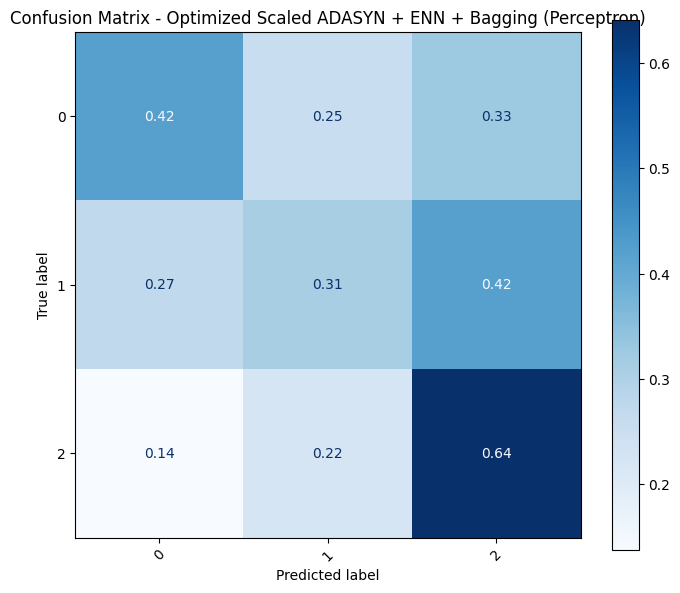

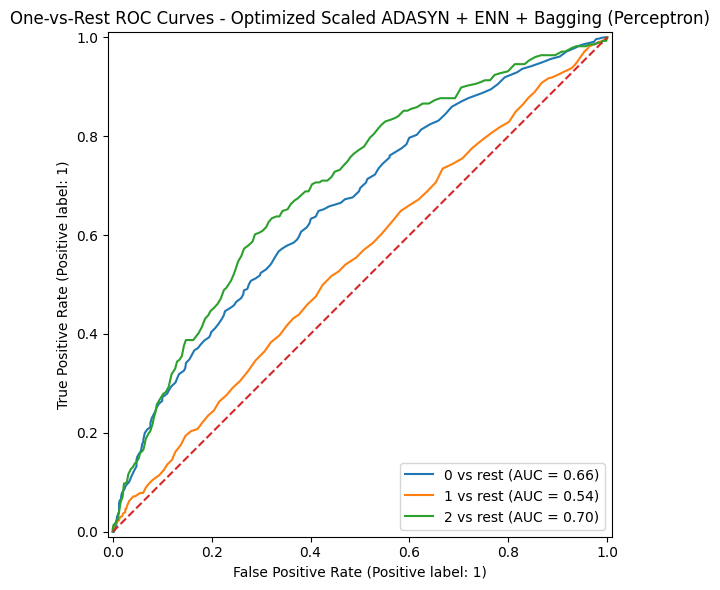

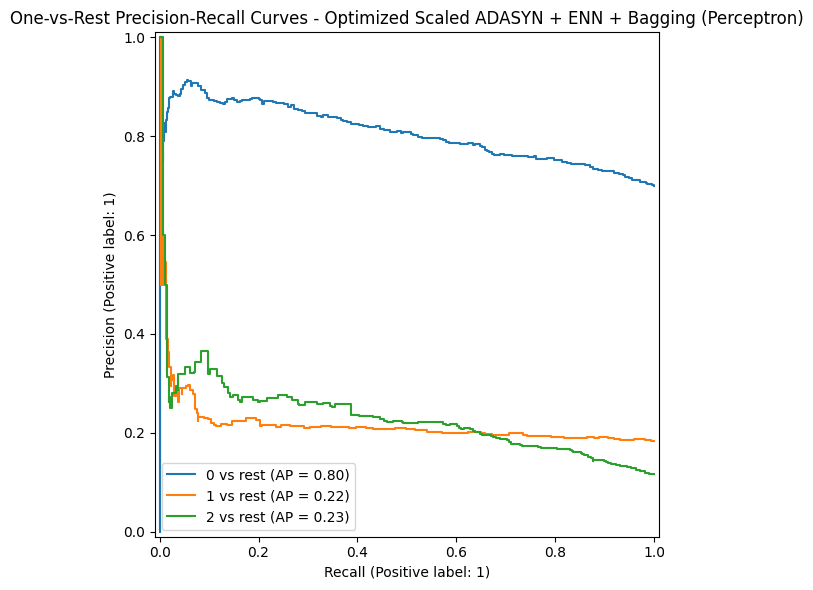


Classification report - Optimized Scaled ADASYN + ENN + Bagging (Perceptron)


,precision,recall,f1-score,support
0,0.816785,0.420572,0.555243,1643.00000
1,0.218597,0.309469,0.256214,433.00000
2,0.198208,0.641304,0.302823,276.00000
accuracy,0.426020,0.426020,0.426020,0.42602
macro avg,0.411197,0.457115,0.371427,2352.00000
weighted avg,0.634071,0.426020,0.470572,2352.00000


In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler              # Essenziale per il calcolo delle distanze geometriche (ADASYN/ENN)
from imblearn.over_sampling import ADASYN                          
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline          # Previene il Data Leakage in Cross-Validation

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_hybrid_bag_perceptron = {
    # Parametri ADASYN ed ENN (esterni all'ensemble)
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], 
    
    # Parametri del Bagging (notare il prefisso 'bag__')
    'bag__n_estimators': [50, 100, 200, 300], # Numero di Perceptron nell'ensemble
    'bag__max_samples': [0.5, 0.7, 0.9, 1.0], # Quanti campioni clonare per ogni Perceptron
    'bag__max_features': [0.5, 0.7, 0.9, 1.0], # Quante feature assegnare a ogni Perceptron
    
    # Parametri del Perceptron sottostante (notare il doppio prefisso 'bag__estimator__')
    'bag__estimator__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'bag__estimator__penalty': ['l2', 'l1', 'elasticnet', None],
    'bag__estimator__max_iter': [1000, 2000],
    'bag__estimator__eta0': [0.1, 0.5, 1.0, 2.0]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE IBRIDA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Configuriamo il Perceptron di base con la gestione dello sbilanciamento
perceptron_base = Perceptron(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier (parallelizzato internamente con n_jobs=-1)
bagging_perceptron_model = BaggingClassifier(estimator=perceptron_base, random_state=42, n_jobs=-1)

# Costruzione della pipeline sequenziale e protetta
pipeline_bag_hybrid_perc = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione (fondamentale per le distanze di ADASYN ed ENN)
    ('adasyn', adasyn_sampler),   # Fase 2: Generazione campioni sintetici sulle minoranze
    ('enn', enn_sampler),         # Fase 3: Pulizia dei confini e rimozione degli outlier rumorosi
    ('bag', bagging_perceptron_model) # Fase 4: Classificazione d'insieme tramite Bagging di Perceptron
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled ADASYN + ENN + Bagging (Perceptron) Hyperparameter Tuning...")

random_search_hybrid_bag_perc = RandomizedSearchCV(
    estimator=pipeline_bag_hybrid_perc,
    param_distributions=param_dist_hybrid_bag_perceptron,
    n_iter=40,                     # Esploriamo 40 combinazioni nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=1,                      # IMPERATIVO: 1 per evitare conflitti di memoria con joblib/imblearn
    random_state=42,
    verbose=1
)

# Fit sui dati originali sbilanciati a 3 classi
random_search_hybrid_bag_perc.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_bag_perc = random_search_hybrid_bag_perc.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_bag_perc.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_bag_perc.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Hybrid Bagging + Perceptron Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_bag_perc,
    X_test=X_test,       # Test set reale sbilanciato (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled ADASYN + ENN + Bagging (Perceptron)",
    normalize_cm="true"
)

## 3 classes, balanced (BalancedBaggingClassifier)

Starting Scaled BalancedBagging + Perceptron Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'bag__n_estimators': 200, 'bag__max_samples': 0.5, 'bag__max_features': 1.0, 'bag__estimator__penalty': 'l2', 'bag__estimator__max_iter': 1000, 'bag__estimator__eta0': 0.5, 'bag__estimator__alpha': 0.01}
Best Balanced Accuracy Score (CV): 0.4839

Evaluating Best Balanced Bagging Model on Test Set...


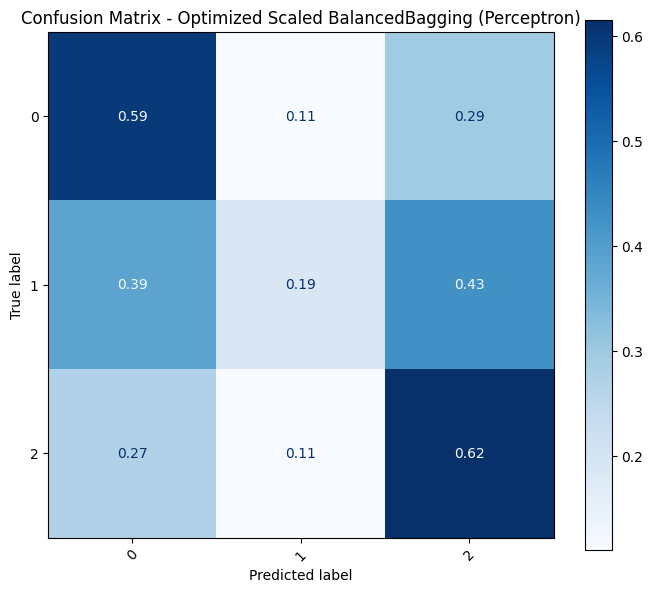

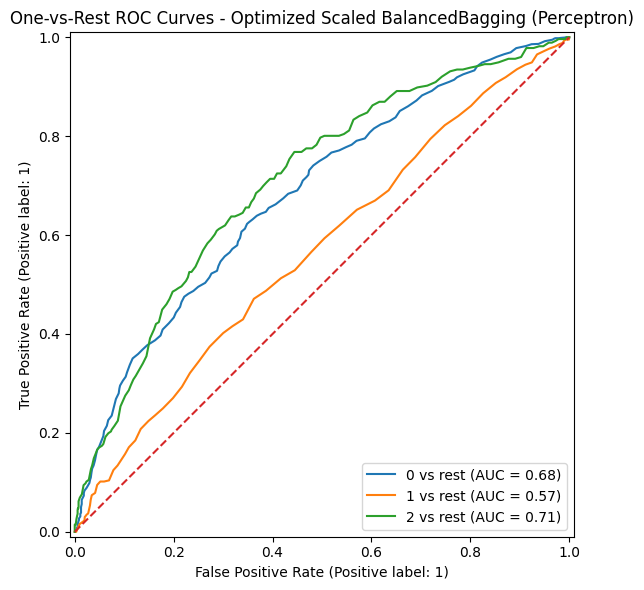

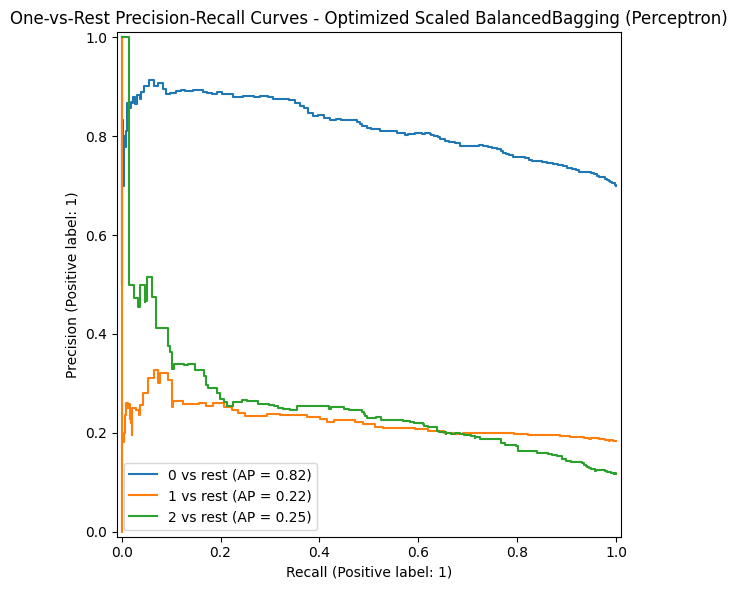


Classification report - Optimized Scaled BalancedBagging (Perceptron)


,precision,recall,f1-score,support
0,0.801477,0.594644,0.682739,1643.000000
1,0.275510,0.187067,0.222834,433.000000
2,0.202622,0.615942,0.304933,276.000000
accuracy,0.522109,0.522109,0.522109,0.522109
macro avg,0.426536,0.465884,0.403502,2352.000000
weighted avg,0.634373,0.522109,0.553737,2352.000000


In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_balanced_bag = {
    # Parametri del BalancedBaggingClassifier (notare il prefisso 'bag__')
    'bag__n_estimators': [50, 100, 200, 300], # Numero di Perceptron nell'ensemble
    'bag__max_samples': [0.5, 0.7, 0.9, 1.0], # Quanti campioni clonare per ogni stimatore
    'bag__max_features': [0.5, 0.7, 0.9, 1.0], # Quante feature assegnare a ogni stimatore
    
    # Parametri del Perceptron sottostante (notare il doppio prefisso 'bag__estimator__')
    'bag__estimator__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'bag__estimator__penalty': ['l2', 'l1', 'elasticnet', None],
    'bag__estimator__max_iter': [1000, 2000],
    'bag__estimator__eta0': [0.1, 0.5, 1.0, 2.0]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE
# =========================================================================
# Configuriamp il Perceptron di base
# Nota: lasciamo class_weight=None perché il bilanciamento è gestito a monte dal BalancedBagging
perceptron_base = Perceptron(random_state=42)

# Istanziamo il BalancedBaggingClassifier
# sampling_strategy='auto' bilancia automaticamente tutte le classi rispetto alla maggioritaria
balanced_bagging_model = BalancedBaggingClassifier(
    estimator=perceptron_base, 
    sampling_strategy='auto',
    random_state=42, 
    n_jobs=-1
)

# Costruzione della pipeline (Scaler + Classificatore d'insieme bilanciato)
pipeline_balanced_bag = ImbPipeline([
    ('scaler', StandardScaler()),         # Fase 1: Standardizzazione delle feature
    ('bag', balanced_bagging_model)       # Fase 2: Bilanciamento interno e Classificazione Ensemble
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled BalancedBagging + Perceptron Hyperparameter Tuning...")

random_search_balanced_bag = RandomizedSearchCV(
    estimator=pipeline_balanced_bag,
    param_distributions=param_dist_balanced_bag,
    n_iter=40,                     # Esploriamo 40 combinazioni nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=1,                      # 1 per evitare conflitti di parallelismo tra joblib e l'ensemble
    random_state=42,
    verbose=1
)

# Fit sui dati originali sbilanciati a 3 classi
random_search_balanced_bag.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_bag = random_search_balanced_bag.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_balanced_bag.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_balanced_bag.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Balanced Bagging Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_bag,
    X_test=X_test,       # Test set reale sbilanciato (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled BalancedBagging (Perceptron)",
    normalize_cm="true"
)

## 4. **Boosting (AdaBoost)**

## 4 classes, imbalanced

Starting AdaBoost + Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'learning_rate': 0.05, 'estimator__min_samples_split': 5, 'estimator__max_depth': 5, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.3626

Evaluating Best AdaBoost Model on Test Set...


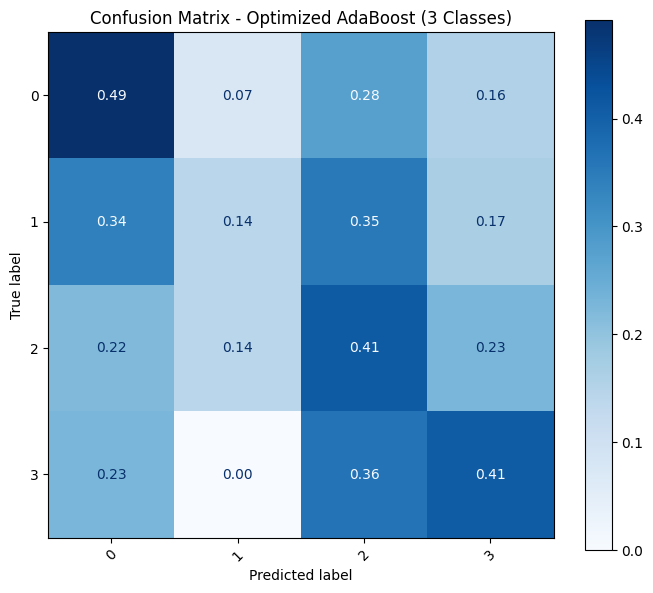

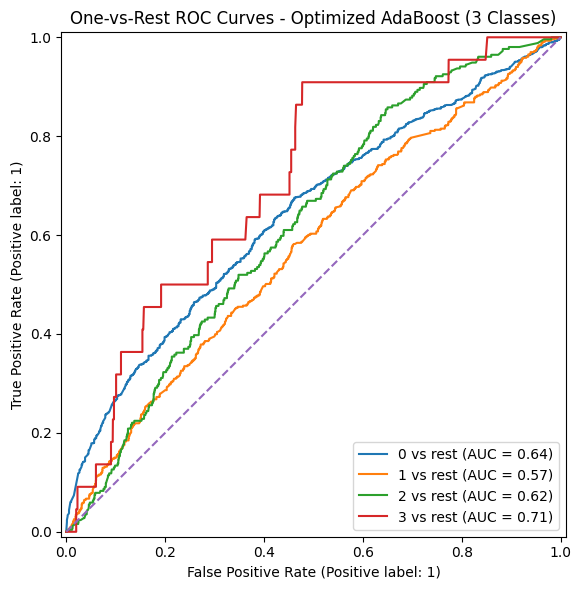

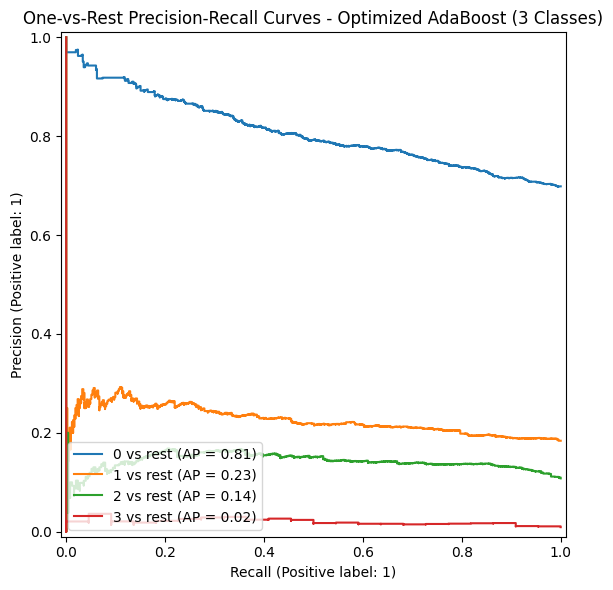


Classification report - Optimized AdaBoost (3 Classes)


,precision,recall,f1-score,support
0,0.795276,0.491783,0.607747,1643.000000
1,0.277273,0.140878,0.186830,433.000000
2,0.144645,0.409449,0.213772,254.000000
3,0.022670,0.409091,0.042959,22.000000
accuracy,0.417517,0.417517,0.417517,0.417517
macro avg,0.309966,0.362800,0.262827,2352.000000
weighted avg,0.622422,0.417517,0.482427,2352.000000


In [37]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per modificare le proprietà dell'albero base
param_dist_adaboost = {
    # Parametri di AdaBoost
    'n_estimators': [50, 100, 200, 300, 500],   # Numero di round di boosting
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0], # Quanto ogni albero corregge il precedente
    
    # Parametri del Decision Tree di base
    # Nota: AdaBoost storicamente usa alberi poco profondi (es. max_depth tra 1 e 5)
    'estimator__max_depth': [1, 2, 3, 5],        
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10]
}

# Configuriamp il Decision Tree di base con il bilanciamento delle classi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo l'AdaBoostClassifier passando l'albero come stimatore principale
adaboost_base = AdaBoostClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting AdaBoost + Decision Tree Hyperparameter Tuning...")

random_search_ada = RandomizedSearchCV(
    estimator=adaboost_base,
    param_distributions=param_dist_adaboost,
    n_iter=40,                     # 40 combinazioni stocastiche
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Focus sul recupero delle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_ada.fit(X_train, y_train)

# Estrazione del modello migliore
best_adaboost = random_search_ada.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_ada.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_ada.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best AdaBoost Model on Test Set...")

# Essendo un modello nativo sklearn, passiamo direttamente l'oggetto alla tua funzione
results, report_df = evaluate_classifier(
    model=best_adaboost,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized AdaBoost (3 Classes)",
    normalize_cm="true"
)

## 3 classes, imbalanced

In [37]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (5487, 32), Test size: (2352, 32)
Puoi lanciare la tua RandomizedSearch


Starting AdaBoost + Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'learning_rate': 0.05, 'estimator__min_samples_split': 5, 'estimator__max_depth': 5, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.4877

Evaluating Best AdaBoost Model on Test Set...


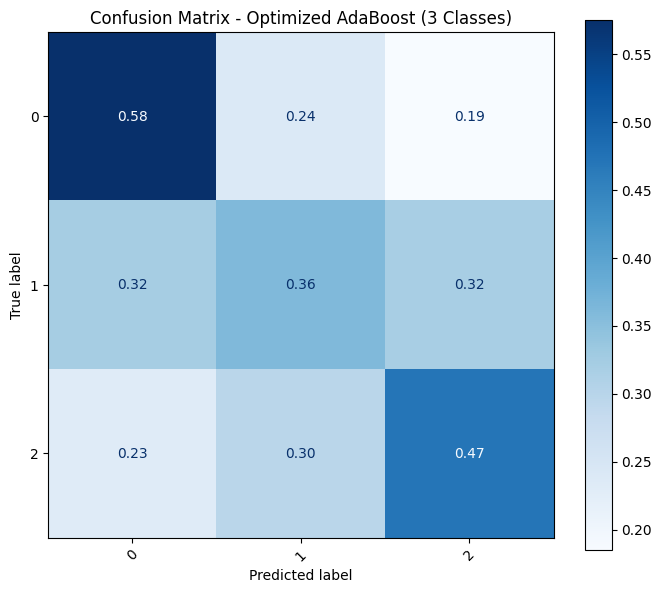

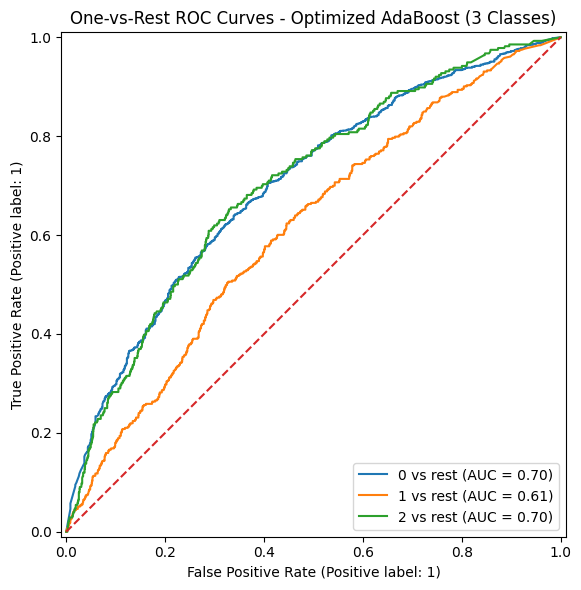

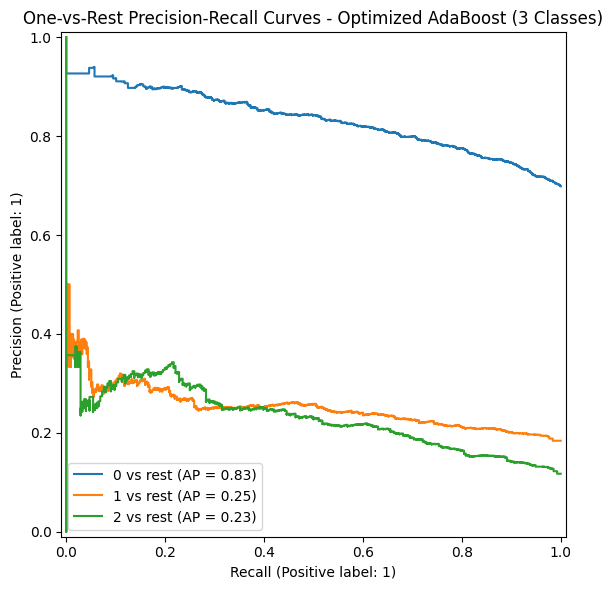


Classification report - Optimized AdaBoost (3 Classes)


,precision,recall,f1-score,support
0,0.823171,0.575167,0.677177,1643.000000
1,0.246835,0.360277,0.292958,433.000000
2,0.227273,0.471014,0.306604,276.000000
accuracy,0.523384,0.523384,0.523384,0.523384
macro avg,0.432426,0.468820,0.425579,2352.000000
weighted avg,0.647141,0.523384,0.562957,2352.000000


In [34]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per modificare le proprietà dell'albero base
param_dist_adaboost = {
    # Parametri di AdaBoost
    'n_estimators': [50, 100, 200, 300, 500],   # Numero di round di boosting
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0], # Quanto ogni albero corregge il precedente
    
    # Parametri del Decision Tree di base
    # Nota: AdaBoost storicamente usa alberi poco profondi (es. max_depth tra 1 e 5)
    'estimator__max_depth': [1, 2, 3, 5],        
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10]
}

# Configuriamp il Decision Tree di base con il bilanciamento delle classi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo l'AdaBoostClassifier passando l'albero come stimatore principale
adaboost_base = AdaBoostClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting AdaBoost + Decision Tree Hyperparameter Tuning...")

random_search_ada = RandomizedSearchCV(
    estimator=adaboost_base,
    param_distributions=param_dist_adaboost,
    n_iter=50,                     # 50 combinazioni stocastiche
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Focus sul recupero delle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_ada.fit(X_train, y_train)

# Estrazione del modello migliore
best_adaboost = random_search_ada.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_ada.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_ada.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best AdaBoost Model on Test Set...")

# Essendo un modello nativo sklearn, passiamo direttamente l'oggetto alla tua funzione
results, report_df = evaluate_classifier(
    model=best_adaboost,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized AdaBoost (3 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

Starting Scaled ADASYN + ENN + AdaBoost Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'enn__n_neighbors': 5, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 3, 'ada__n_estimators': 50, 'ada__learning_rate': 0.5, 'ada__estimator__min_samples_split': 10, 'ada__estimator__max_depth': 3, 'ada__estimator__criterion': 'entropy'}
Best Balanced Accuracy Score (CV): 0.4794

Evaluating Best Hybrid AdaBoost Model on Test Set...


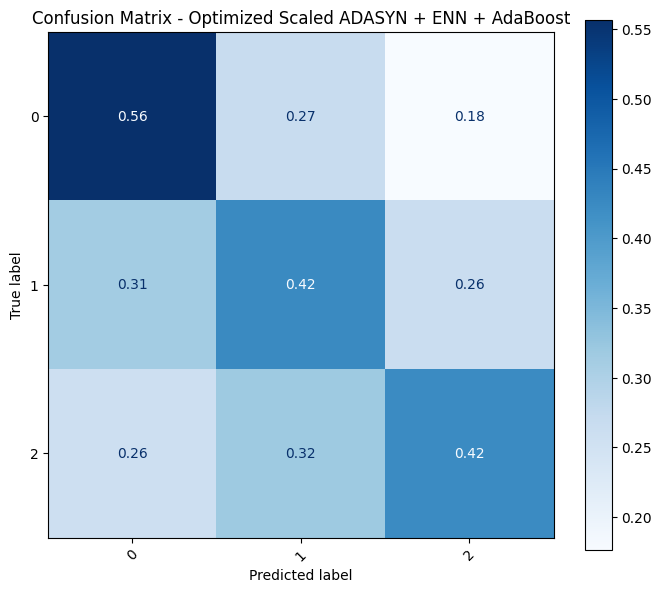

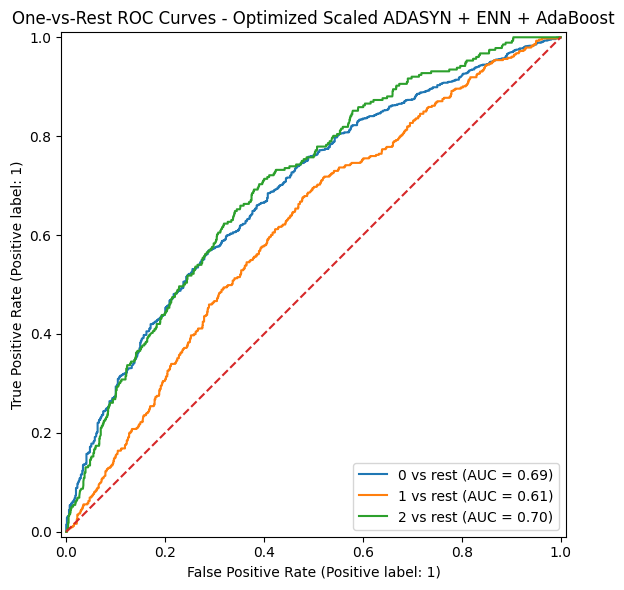

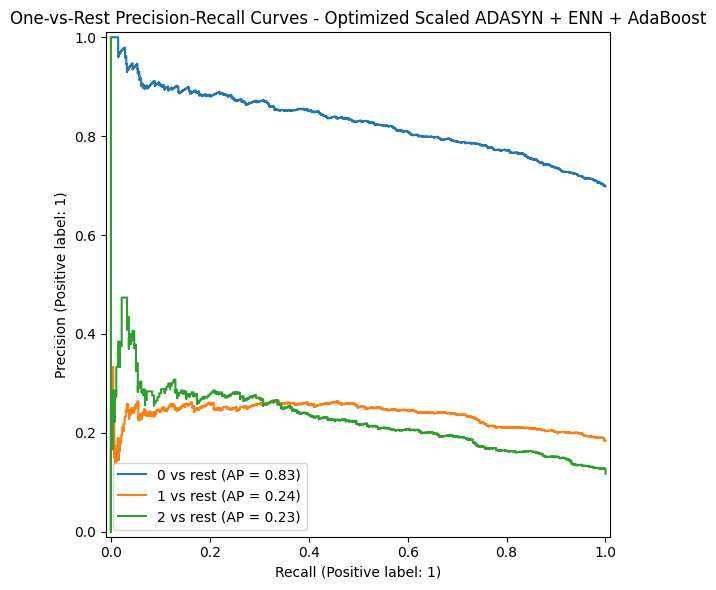


Classification report - Optimized Scaled ADASYN + ENN + AdaBoost


,precision,recall,f1-score,support
0,0.816236,0.556908,0.662084,1643.000000
1,0.259155,0.424942,0.321960,433.000000
2,0.224568,0.423913,0.293601,276.000000
accuracy,0.517007,0.517007,0.517007,0.517007
macro avg,0.433320,0.468588,0.425882,2352.000000
weighted avg,0.644247,0.517007,0.556227,2352.000000


In [35]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler                   # Per garantire il calcolo corretto delle distanze
from imblearn.over_sampling import ADASYN                          
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline              # Protezione da Data Leakage

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_hybrid_ada = {
    # Parametri ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], 
    
    # Parametri di AdaBoost (notare il prefisso 'ada__')
    'ada__n_estimators': [50, 100, 200, 300, 500],   
    'ada__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0], 
    
    # Parametri del Decision Tree sottostante (notare il doppio prefisso 'ada__estimator__')
    'ada__estimator__max_depth': [1, 2, 3, 5],        
    'ada__estimator__criterion': ['gini', 'entropy'],
    'ada__estimator__min_samples_split': [2, 5, 10]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE IBRIDA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Configuriamp il Decision Tree di base con il bilanciamento delle classi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo l'AdaBoostClassifier passando l'albero come stimatore principale
# Nota: AdaBoost non supporta nativamente n_jobs perché è un algoritmo strettamente sequenziale
adaboost_base = AdaBoostClassifier(estimator=dt_base, random_state=42)

# Costruzione della pipeline sequenziale e protetta
pipeline_ada_hybrid = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione per lo spazio dei K-NN
    ('adasyn', adasyn_sampler),   # Fase 2: Oversampling adattivo
    ('enn', enn_sampler),         # Fase 3: Pulizia chirurgica delle sovrapposizioni
    ('ada', adaboost_base)        # Fase 4: Classificazione sequenziale adattiva
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled ADASYN + ENN + AdaBoost Hyperparameter Tuning...")

random_search_hybrid_ada = RandomizedSearchCV(
    estimator=pipeline_ada_hybrid,
    param_distributions=param_dist_hybrid_ada,
    n_iter=50,                     # 50 combinazioni casuali
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=-1,                     # Qui possiamo usare -1 in sicurezza perché AdaBoost non ha parallelismo interno
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
# La pipeline applicherà la trasformazione e i campionamenti fold per fold
random_search_hybrid_ada.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_ada = random_search_hybrid_ada.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_ada.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_ada.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Hybrid AdaBoost Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_ada,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled ADASYN + ENN + AdaBoost",
    normalize_cm="true"
)

## 3 classes, balanced (ENN)

Starting Scaled ENN + AdaBoost Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
7 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\leona\AppData


=== TUNING COMPLETATO ===
Best Parameters found: {'enn__n_neighbors': 3, 'enn__kind_sel': 'mode', 'ada__n_estimators': 500, 'ada__learning_rate': 0.01, 'ada__estimator__min_samples_split': 2, 'ada__estimator__max_depth': 3, 'ada__estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.4547

Evaluating Best Hybrid AdaBoost Model on Test Set...


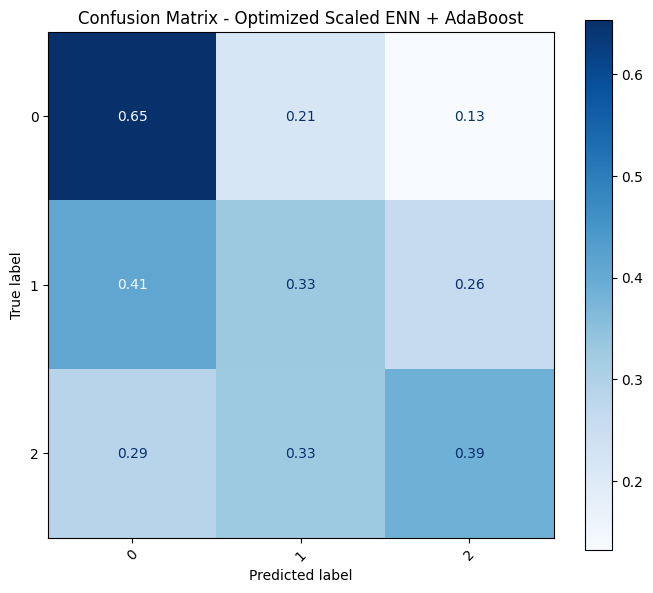

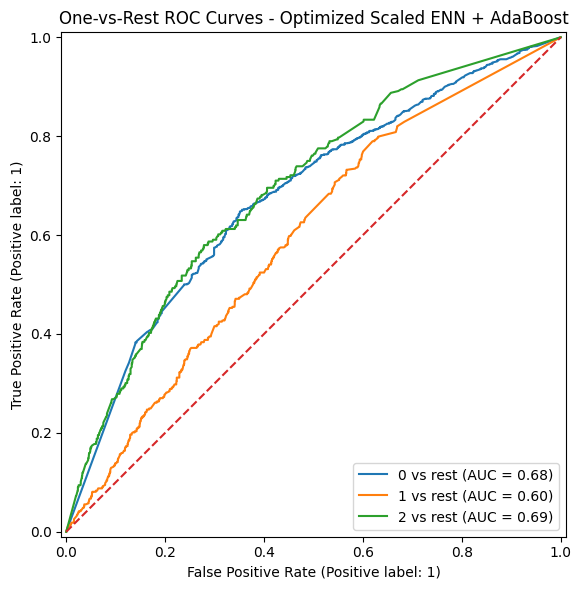

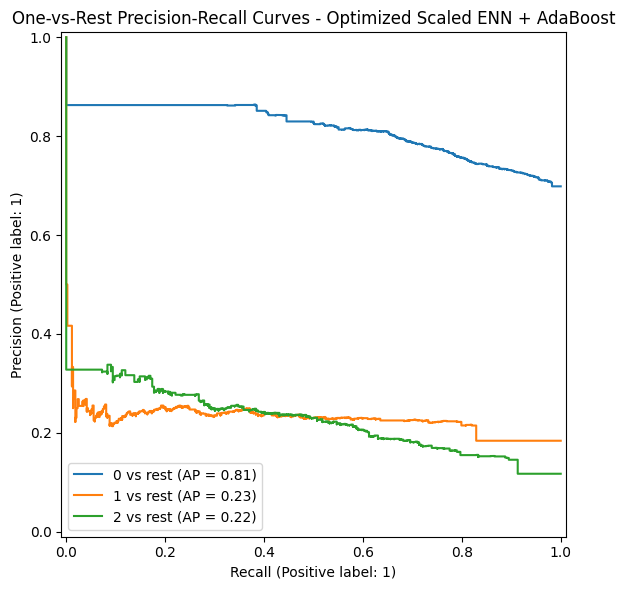


Classification report - Optimized Scaled ENN + AdaBoost


,precision,recall,f1-score,support
0,0.806912,0.653682,0.722260,1643.0000
1,0.243151,0.327945,0.279253,433.0000
2,0.244851,0.387681,0.300140,276.0000
accuracy,0.562500,0.562500,0.562500,0.5625
macro avg,0.431638,0.456436,0.433884,2352.0000
weighted avg,0.637168,0.562500,0.591168,2352.0000


In [38]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler                   # Per garantire il calcolo corretto delle distanze                      
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline              # Protezione da Data Leakage

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_hybrid_ada = {
    # Parametri ENN
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], 
    
    # Parametri di AdaBoost (notare il prefisso 'ada__')
    'ada__n_estimators': [50, 100, 200, 300, 500],   
    'ada__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0], 
    
    # Parametri del Decision Tree sottostante (notare il doppio prefisso 'ada__estimator__')
    'ada__estimator__max_depth': [1, 2, 3, 5],        
    'ada__estimator__criterion': ['gini', 'entropy'],
    'ada__estimator__min_samples_split': [2, 5, 10]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE IBRIDA
# =========================================================================
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Configuriamp il Decision Tree di base con il bilanciamento delle classi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo l'AdaBoostClassifier passando l'albero come stimatore principale
# Nota: AdaBoost non supporta nativamente n_jobs perché è un algoritmo strettamente sequenziale
adaboost_base = AdaBoostClassifier(estimator=dt_base, random_state=42)

# Costruzione della pipeline sequenziale e protetta
pipeline_ada_hybrid = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione per lo spazio dei K-NN
    ('enn', enn_sampler),         # Fase 2: Pulizia chirurgica delle sovrapposizioni
    ('ada', adaboost_base)        # Fase 3: Classificazione sequenziale adattiva
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled ENN + AdaBoost Hyperparameter Tuning...")

random_search_hybrid_ada = RandomizedSearchCV(
    estimator=pipeline_ada_hybrid,
    param_distributions=param_dist_hybrid_ada,
    n_iter=50,                     # 50 combinazioni casuali
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=-1,                     # Qui possiamo usare -1 in sicurezza perché AdaBoost non ha parallelismo interno
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
# La pipeline applicherà la trasformazione e i campionamenti fold per fold
random_search_hybrid_ada.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_ada = random_search_hybrid_ada.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_ada.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_ada.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Hybrid AdaBoost Model on Test Set...")

# Lanciamo la valutazione passando direttamente la pipeline ottimizzata
results, report_df = evaluate_classifier(
    model=best_pipeline_ada,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized Scaled ENN + AdaBoost",
    normalize_cm="true"
)